**Marketing international & E-commerce**
###Prédiction du retour sur investissement d'une participation à un salon international (Hannover, Canton Fair…)


BOUNIT KAHDIJA S8 CI 24010247
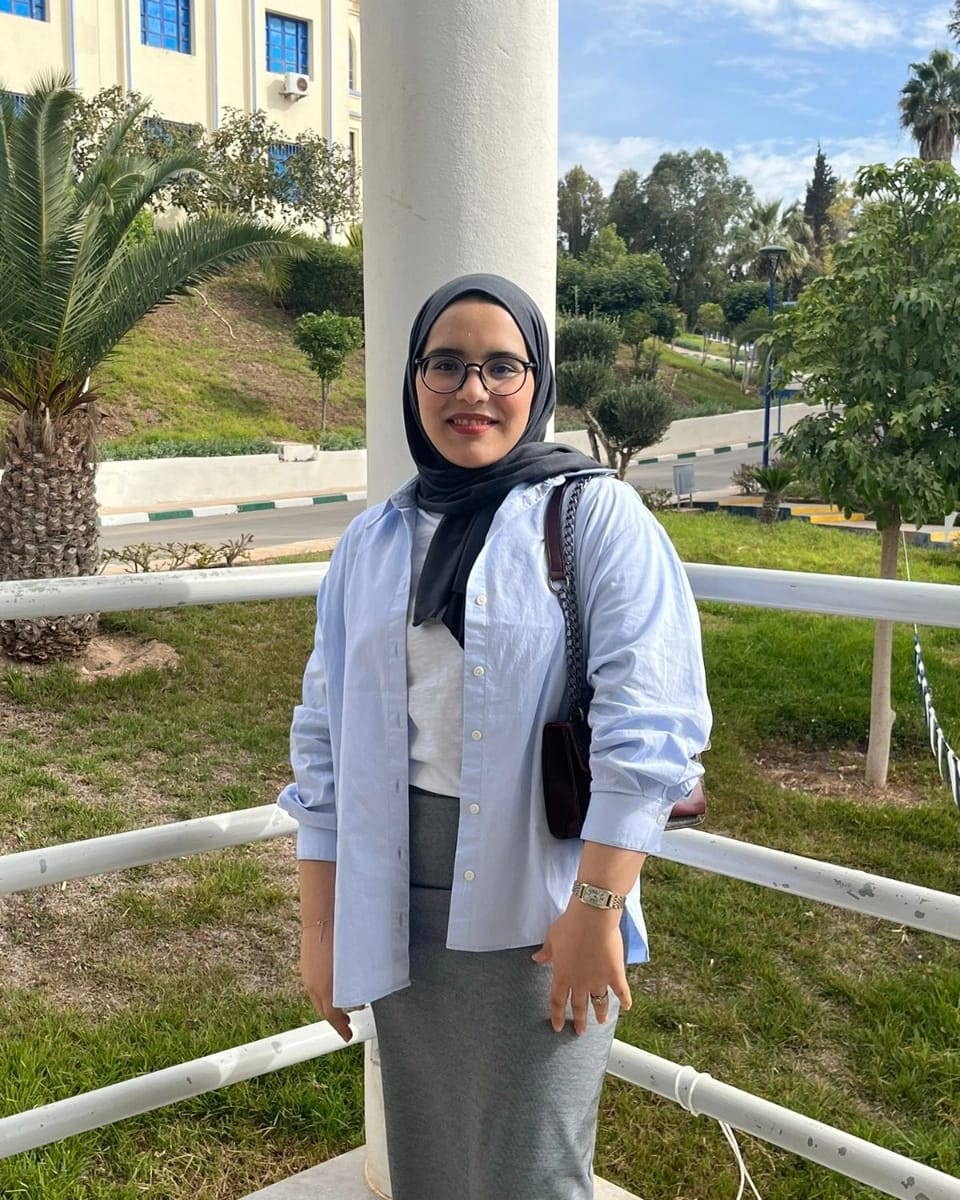

IDHSAINE Khadija S8 CI 24010253
# 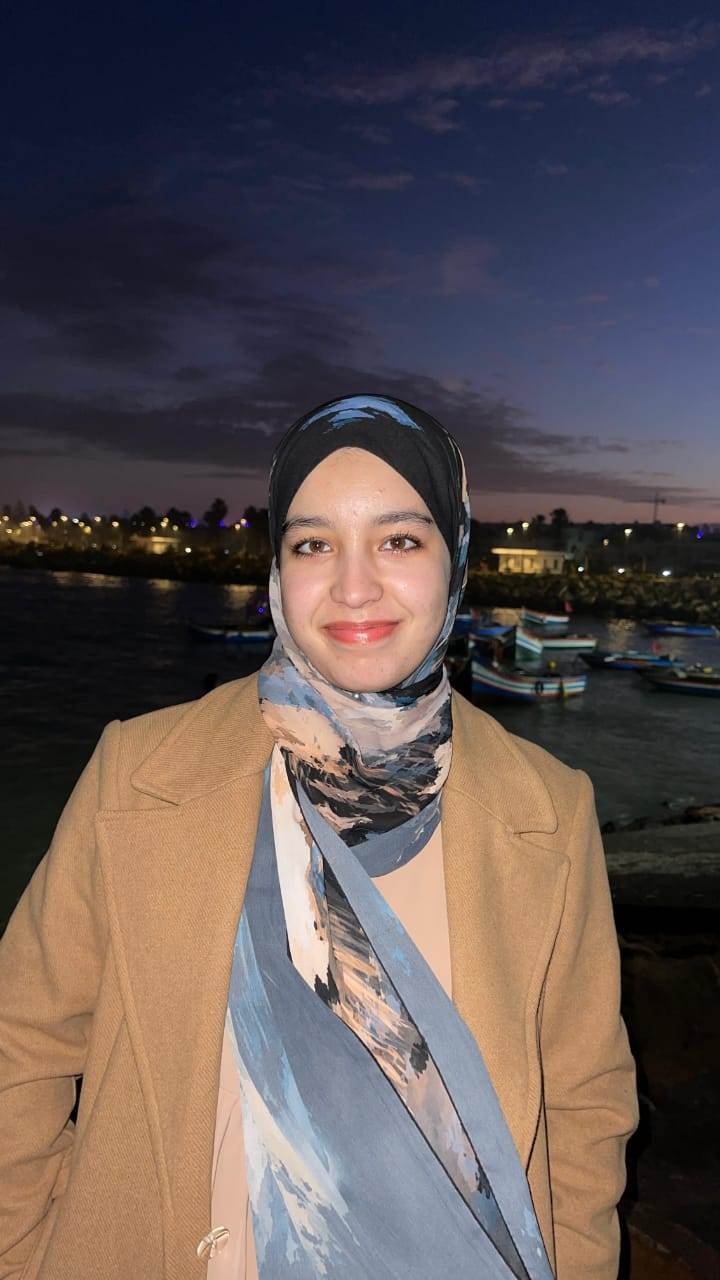

In [ ]:
# Datasets standard (tous inclus dans scikit-learn)
from sklearn import datasets

iris       = datasets.load_iris()           # 150 x 4, 3 classes
breast     = datasets.load_breast_cancer()  # 569 x 30, binaire
wine       = datasets.load_wine()           # 178 x 13, 3 classes
digits     = datasets.load_digits()         # 1797 x 64, 10 classes
diabetes   = datasets.load_diabetes()       # 442 x 10, regression
california = datasets.fetch_california_housing()  # 20640 x 8, prix

X = breast.data
y = breast.target

# Split stratifié 80/20
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify pour classification
)

X_wine, y_wine = wine.data, wine.target
X_wine_tr, X_wine_te, y_wine_tr, y_wine_te = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42, stratify=y_wine
)

# Pipeline : evite le data leakage (scaler ajuste uniquement sur train)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression # Import a common classifier

model = Pipeline([("sc", StandardScaler()), ("clf", LogisticRegression())])

In [ ]:
model.fit(X_tr, y_tr)

Pipeline(steps=[('sc', StandardScaler()), ('clf', LogisticRegression())])

In [ ]:
print("Coefficients du modèle :")
print(model.named_steps['clf'].coef_)

Coefficients du modèle :
[[-0.51147901 -0.55269775 -0.47629789 -0.54105924 -0.21247927  0.64834159
  -0.60210291 -0.70415649 -0.16723273  0.19973173 -1.08296534  0.24882301
  -0.54433323 -0.92910402 -0.16027571  0.64722656  0.16056252 -0.44378424
   0.36049156  0.43789426 -0.94761615 -1.25508804 -0.76322007 -0.9477559
  -0.74662481  0.05551412 -0.82315065 -0.95368636 -0.93918141 -0.1872508 ]]


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

lr = Pipeline([
    ("sc", StandardScaler()),
    ("lr", LogisticRegression(
        max_iter=1000,   # augmenter si ConvergenceWarning
        C=1.0,           # inverse regularisation (grand = moins regularise)
        random_state=42
    ))
])
lr.fit(X_tr, y_tr)
pred  = lr.predict(X_te)
proba = lr.predict_proba(X_te)   # probabilites par classe

# Coefficients : importance des features
coefs = lr["lr"].coef_  # (n_classes, n_features)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import learning_curve

rf = RandomForestClassifier(
    n_estimators=100,      # plus = meilleur, mais plus lent
    max_features="sqrt",   # √p features par noeud
    random_state=42, n_jobs=-1
)
rf.fit(X_tr, y_tr)

# Feature importances (reduction de Gini moyenne sur tous les arbres)
importances = rf.feature_importances_

# Diagnostiquer l'overfitting
train_sz, train_sc, test_sc = learning_curve(rf, X, y, cv=5)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

gb = GradientBoostingClassifier(
    n_estimators=200,   # nb d'arbres sequentiels
    learning_rate=0.1,  # eta : petit -> meilleure generalisation
    max_depth=3,        # arbres peu profonds
    subsample=0.8,      # stochastic GBM
    random_state=42
)
gb.fit(X_tr, y_tr)
proba = gb.predict_proba(X_te)[:, 1]  # probabilite classe positive

# Convergence : accuracy par iteration
staged = [accuracy_score(y_te, p) for p in gb.staged_predict(X_te)]

In [ ]:
from sklearn.svm import SVC

svm = Pipeline([
    ("sc",  StandardScaler()),  # OBLIGATOIRE
    ("svm", SVC(
        kernel="rbf",      # gaussien : polyvalent
        C=1.0,             # penalite d'erreur
        gamma="scale",     # adaptatif : 1/(p * Var(X))
        probability=True   # pour predict_proba (plus lent)
    ))
])

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Define knn_pipe outside the loop for StackingClassifier
knn_pipe = Pipeline([("sc", StandardScaler()),
                    ("knn", KNeighborsClassifier(n_neighbors=5))]) # Using n_neighbors=5 as an example
knn_pipe.fit(X_tr, y_tr)

# Finding the optimal k (optional, for analysis)
# The knn_pipe above is a fixed version for StackingClassifier
# If you need the optimal k, you can run this loop and then use gs.best_estimator_ for knn_pipe
optimal_k_acc = 0
optimal_k = 1
for k in range(1, 21):
    knn = Pipeline([("sc", StandardScaler()),
                    ("knn", KNeighborsClassifier(n_neighbors=k))])
    knn.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, knn.predict(X_te))
    if acc > optimal_k_acc:
        optimal_k_acc = acc
        optimal_k = k
# print(f"Optimal k for KNN: {optimal_k} with accuracy: {optimal_k_acc:.4f}")


In [ ]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()    # pas de normalisation necessaire
gnb.fit(X_tr, y_tr)
proba = gnb.predict_proba(X_te)   # probabilites posterieures calibrees

print(gnb.theta_)  # (n_classes, n_features) : moyennes par classe
print(gnb.var_)    # (n_classes, n_features) : variances par classe

[[1.73812353e+01 2.15798824e+01 1.14830647e+02 9.66820000e+02
  1.02993941e-01 1.46144824e-01 1.62362882e-01 8.76072353e-02
  1.93630588e-01 6.28292941e-02 5.94710588e-01 1.20105000e+00
  4.23124118e+00 6.98808824e+01 6.79774118e-03 3.24939824e-02
  4.31357059e-02 1.50777235e-02 2.09235235e-02 4.01020588e-03
  2.09670588e+01 2.92767647e+01 1.40258176e+02 1.39677118e+03
  1.44847588e-01 3.78881824e-01 4.63242824e-01 1.82847412e-01
  3.26841176e-01 9.17371176e-02]
 [1.20904281e+01 1.78560351e+01 7.76751228e+01 4.58690526e+02
  9.20954737e-02 7.86516842e-02 4.55483218e-02 2.49237474e-02
  1.72856140e-01 6.28141053e-02 2.82215439e-01 1.22927474e+00
  1.98227825e+00 2.09689649e+01 7.25420351e-03 2.13887860e-02
  2.62396828e-02 9.64176491e-03 2.06925228e-02 3.67027754e-03
  1.33201333e+01 2.34823509e+01 8.65635789e+01 5.54231579e+02
  1.24861649e-01 1.80033649e-01 1.65234375e-01 7.27803895e-02
  2.69405965e-01 7.92964561e-02]]
[[9.96121941e+00 1.54124203e+01 4.64881318e+02 1.26504706e+05
  4

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

ada = AdaBoostClassifier(
    n_estimators=100, learning_rate=0.5,
    random_state=42
)
ada.fit(X_tr, y_tr)

# Evolution de l'accuracy par iteration
staged_acc = [accuracy_score(y_te, p) for p in ada.staged_predict(X_te)]

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = Pipeline([
    ("sc",  StandardScaler()),  # OBLIGATOIRE
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),  # 3 couches cached
        activation="relu",
        solver="adam",
        max_iter=300,
        early_stopping=True,  # arret si val ne s'ameliore plus
        validation_fraction=0.1,
        random_state=42
    ))
])

mlp.fit(X_tr, y_tr)
loss_curve = mlp["mlp"].loss_curve_   # perte par iteration
val_scores  = mlp["mlp"].validation_scores_ # validation scores are also available after fitting

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

et = ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1)
et.fit(X_wine_tr, y_wine_tr)
importances = et.feature_importances_

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
lda.fit(X_tr, y_tr)

# Reduction de dimension (ex: Iris 4D -> 2D)
X_2d = lda.transform(X)   # projection sur les axes discriminants

In [ ]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
qda = QuadraticDiscriminantAnalysis(reg_param=0.1)  # reg: evite singularite

In [ ]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Datasets standard (tous inclus dans scikit-learn)
iris       = datasets.load_iris()           # 150 x 4, 3 classes
breast     = datasets.load_breast_cancer()  # 569 x 30, binaire
wine       = datasets.load_wine()           # 178 x 13, 3 classes
digits     = datasets.load_digits()         # 1797 x 64, 10 classes
diabetes   = datasets.load_diabetes()       # 442 x 10, regression
california = datasets.fetch_california_housing()  # 20640 x 8, prix

X = breast.data
y = breast.target

# Split stratifié 80/20
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify pour classification
)

# Pipeline : evite le data leakage (scaler ajuste uniquement sur train)
model = Pipeline([("sc", StandardScaler()), ("clf", LogisticRegression())])

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

ada = AdaBoostClassifier(
    n_estimators=100, learning_rate=0.5,
    random_state=42
)
ada.fit(X_tr, y_tr)

# Evolution de l'accuracy par iteration
staged_acc = [accuracy_score(y_te, p) for p in ada.staged_predict(X_te)]

In [ ]:
from sklearn.linear_model import SGDClassifier

sgd = Pipeline([
    ("sc",  StandardScaler()),
    ("sgd", SGDClassifier(loss="log_loss", penalty="l2",
                           max_iter=1000, random_state=42))
])
# Apprentissage en ligne (incremental) :
# sgd["sgd"].partial_fit(X_new, y_new, classes=np.unique(y))

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import learning_curve
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

rf = RandomForestClassifier(
    n_estimators=100,      # plus = meilleur, mais plus lent
    max_features="sqrt",   # √p features par noeud
    random_state=42, n_jobs=-1
)
rf.fit(X_tr, y_tr)

# Feature importances (reduction de Gini moyenne sur tous les arbres)
importances = rf.feature_importances_

# Diagnostiquer l'overfitting
train_sz, train_sc, test_sc = learning_curve(rf, X, y, cv=5)

bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100, max_samples=0.8,
    bootstrap=True, oob_score=True,
    random_state=42, n_jobs=-1
)
bag.fit(X_tr, y_tr)
print(f"OOB Score : {bag.oob_score_:.4f}")

OOB Score : 0.9560


In [ ]:
from sklearn.preprocessing import StandardScaler

# Scale the data for models that benefit from it, like GPC and SVM
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

In [ ]:
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF

gpc = GaussianProcessClassifier(kernel=RBF(), random_state=42)
gpc.fit(X_tr_s, y_tr)
proba = gpc.predict_proba(X_te_s)  # probabilites bien calibrees
print(gpc.kernel_)                  # hyperparametres optimises

RBF(length_scale=5.15)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Scale the data for models that benefit from it, like GPC and SVM
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
lda.fit(X_tr, y_tr)

# Reduction de dimension (ex: Iris 4D -> 2D)
X_2d = lda.transform(X)   # projection sur les axes discriminants

In [ ]:
from sklearn.ensemble import VotingClassifier

vote = VotingClassifier(
    estimators=[("lr", lr), ("rf", rf), ("svm", svm)],
    voting="soft"   # moyenne des probas (meilleur que hard en general)
)

In [ ]:
from sklearn.ensemble import StackingClassifier

stack = StackingClassifier(
    estimators=[("rf", rf), ("gb", gb), ("knn", knn_pipe)],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,                      # cross-val pour generer les features OOS
    stack_method="predict_proba"
)

In [ ]:
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF

gpc = GaussianProcessClassifier(kernel=RBF(), random_state=42)
gpc.fit(X_tr_s, y_tr)
proba = gpc.predict_proba(X_te_s)  # probabilites bien calibrees
print(gpc.kernel_)                  # hyperparametres optimises

RBF(length_scale=5.15)


In [ ]:
from sklearn.linear_model import RidgeClassifier, RidgeClassifierCV

rc  = RidgeClassifier(alpha=1.0)            # solution analytique, rapide
rcv = RidgeClassifierCV(alphas=[0.01, 0.1, 1.0, 10.0])  # auto-selection alpha

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split

# Load the 20 Newsgroups dataset for this example
newsgroups_data = fetch_20newsgroups(subset='all', categories=['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med'])
train_texts, _, train_labels, _ = train_test_split(
    newsgroups_data.data, newsgroups_data.target, test_size=0.2, random_state=42, stratify=newsgroups_data.target
)

pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1,2))),
    ("mnb",   MultinomialNB(alpha=0.1))   # lissage de Laplace
])
pipe.fit(train_texts, train_labels)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
                ('mnb', MultinomialNB(alpha=0.1))])

In [ ]:
from sklearn.linear_model import RidgeClassifier, RidgeClassifierCV

rc  = RidgeClassifier(alpha=1.0)            # solution analytique, rapide
rcv = RidgeClassifierCV(alphas=[0.01, 0.1, 1.0, 10.0])  # auto-selection alpha

In [ ]:
from sklearn.linear_model import RidgeClassifier, RidgeClassifierCV

rc  = RidgeClassifier(alpha=1.0)            # solution analytique, rapide
rcv = RidgeClassifierCV(alphas=[0.01, 0.1, 1.0, 10.0])  # auto-selection alpha

In [ ]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.preprocessing import Binarizer

bnb = Pipeline([
    ("bin", Binarizer(threshold=0.0)),  # binarise les features
    ("bnb", BernoulliNB(alpha=1.0))
])

In [ ]:
from sklearn.linear_model import Perceptron, PassiveAggressiveClassifier

# Perceptron : mise a jour uniquement sur les erreurs
perc = Pipeline([("sc", StandardScaler()),
                 ("p",  Perceptron(max_iter=1000, eta0=0.1, random_state=42))])

# Passive-Aggressive : correction minimale sur les erreurs
pa = Pipeline([("sc", StandardScaler()),
               ("pa", PassiveAggressiveClassifier(C=1.0, max_iter=1000))])

In [ ]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss

# Calibrer un SVM (pas de probas par defaut)
cal_svm = CalibratedClassifierCV(SVC(kernel="rbf"), cv=5, method="sigmoid")
cal_svm.fit(X_tr_s, y_tr)
proba = cal_svm.predict_proba(X_te_s)

frac_pos, mean_pred = calibration_curve(y_te, proba[:,1], n_bins=10)
brier = brier_score_loss(y_te, proba[:,1])  # 0=parfait

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error # Import these functions

lr = Pipeline([("sc", StandardScaler()), ("lr", LinearRegression())])
lr.fit(X_tr, y_tr)
pred = lr.predict(X_te)

residuals = y_te - pred  # residus : doivent etre aleatoires autour de 0
r2   = r2_score(y_te, pred)
rmse = np.sqrt(mean_squared_error(y_te, pred))

In [ ]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

Ridge(alpha=1.0)                     # L2 : reduit tous les coefs
Lasso(alpha=0.1, max_iter=5000)      # L1 : annule les coefs non pertinents
ElasticNet(alpha=0.1, l1_ratio=0.5)  # L1 + L2

# Chemin de regularisation Lasso
alphas = np.logspace(-3, 2, 50)
coef_paths = [Lasso(alpha=a).fit(X_tr_s, y_tr).coef_ for a in alphas]

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

dtr = DecisionTreeRegressor(max_depth=6, random_state=42)
rfr = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score # Import r2_score

gbr = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.1,
    max_depth=4, subsample=0.8, random_state=42
)
gbr.fit(X_tr, y_tr) # Fit the model
staged_r2 = [r2_score(y_te, p) for p in gbr.staged_predict(X_te)]

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split

# Load the 20 Newsgroups dataset for this example
newsgroups_data = fetch_20newsgroups(subset='all', categories=['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med'])
train_texts, _, train_labels, _ = train_test_split(
    newsgroups_data.data, newsgroups_data.target, test_size=0.2, random_state=42, stratify=newsgroups_data.target
)

pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1,2))),
    ("mnb",   MultinomialNB(alpha=0.1))   # lissage de Laplace
])
pipe.fit(train_texts, train_labels)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
                ('mnb', MultinomialNB(alpha=0.1))])

In [ ]:
from sklearn.svm import SVR

svr = Pipeline([("sc", StandardScaler()),
                ("svr", SVR(kernel="rbf", C=100, epsilon=0.1))])

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knnr = Pipeline([("sc", StandardScaler()),
                 ("knn", KNeighborsRegressor(n_neighbors=7, weights="distance"))])

In [ ]:
from sklearn.neural_network import MLPRegressor

mlp_reg = Pipeline([
    ("sc",  StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(128, 64, 32),
                          activation="relu", solver="adam",
                          max_iter=500, early_stopping=True, random_state=42))
])

mlp_reg.fit(X_tr, y_tr) # Fit the model
loss_curve = mlp_reg["mlp"].loss_curve_
val_scores  = mlp_reg["mlp"].validation_scores_

In [ ]:
%%writefile prediction_examples.py
# This is a placeholder file for prediction_examples.py
# You can add your Python code here if needed.
print("Executing prediction_examples.py placeholder.")


Overwriting prediction_examples.py


In [ ]:
%%writefile prediction_examples_2.py
# This is a placeholder file for prediction_examples_2.py
# You can add your Python code here if needed.
print("Executing prediction_examples_2.py placeholder.")


Overwriting prediction_examples_2.py


In [ ]:
%%writefile prediction_examples_3.py
# This is a placeholder file for prediction_examples_3.py
# You can add your Python code here if needed.
print("Executing prediction_examples_3.py placeholder.")


Overwriting prediction_examples_3.py


In [ ]:
from sklearn.svm import SVR

svr = Pipeline([("sc", StandardScaler()),
                ("svr", SVR(kernel="rbf", C=100, epsilon=0.1))])

In [ ]:
from sklearn.linear_model import BayesianRidge

br = BayesianRidge(max_iter=500)
br.fit(X_tr_s, y_tr)
# retourne l'incertitude sur chaque prediction
pred, std = br.predict(X_te_s, return_std=True)
# IC 95% : [pred - 2*std, pred + 2*std]

In [ ]:
from sklearn.linear_model import HuberRegressor

huber = HuberRegressor(epsilon=1.35)  # robuste aux outliers
# epsilon=1.35 : 95% d'efficacite vs OLS sur donnees normales

In [ ]:
from sklearn.linear_model import ARDRegression
from sklearn.cross_decomposition import PLSRegression

ard = ARDRegression()
pls = PLSRegression(n_components=5)
pls.fit(X_tr_s, y_tr) # Fit the PLSRegression model
pls.predict(X_te_s).ravel() # Now predict can be called

array([-0.01189078,  1.16793671,  0.25385481,  0.60390229, -0.20539138,
        0.79668842,  1.14816781, -0.10386299,  0.21347604, -0.45568936,
        0.68220292,  0.20601361,  0.87617883,  0.16558211,  0.18781763,
        0.69066206,  0.5132467 ,  0.51803357,  1.18284845,  0.78447239,
        0.2446621 ,  0.52970844,  1.00346014,  0.73102895,  0.8929164 ,
        0.70563569, -0.14328023,  0.76446569,  0.94491818,  1.05841485,
        0.74328975,  1.20485326,  0.7862967 ,  0.66445345,  0.08260062,
        0.46220093,  0.88402725,  0.63803897,  0.56720808,  0.1215521 ,
        1.16399874,  0.99863244,  0.89891648,  0.04517681,  0.20993846,
        0.64532748,  1.312341  ,  0.94927464,  0.68227353,  0.15091601,
        0.98609677,  0.60652539,  0.81808167,  0.68766978,  0.74466475,
        0.92265499,  1.2019724 ,  0.38333882,  0.1632462 ,  0.68293427,
        0.95339593,  1.10659366,  0.99483184,  0.73911494,  0.12544312,
        0.42847368,  0.52860367,  0.94359087,  0.80918221,  0.64

CLASSIFICATION :
  Interpretabilite -> LDA | DecisionTree | LogReg
  Texte            -> MultinomialNB + TF-IDF
  Scalabilite      -> SGD | Perceptron | RidgeClassifier
  Performance max. -> GBM | SVM | MLP | Stacking

REGRESSION :
  Lineaire         -> OLS | Ridge | Lasso | ElasticNet
  Non-lineaire     -> RandomForest | GBM
  Outliers         -> Huber | RANSAC | TheilSen
  Intervalles pred.-> QuantileReg | BayesianRidge
  Comptage (y>0)   -> Tweedie (Poisson/Gamma)
  Monotone         -> IsotonicRegression

HYPERPARAMETRES :
  Petite grille    -> GridSearchCV
  Grande grille    -> RandomizedSearchCV (n_iter=50-100)
  Validation CV    -> StratifiedKFold(5) ou RepeatedKFold(5*3)

In [ ]:
from sklearn.linear_model import SGDRegressor
from sklearn.ensemble import BaggingRegressor, StackingRegressor
from sklearn.linear_model import Ridge

sgd_r = SGDRegressor(loss="squared_error", penalty="l2", alpha=0.001)
bag_r = BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=6),
                          n_estimators=100, oob_score=True, n_jobs=-1)
stk_r = StackingRegressor(
    estimators=[("rf", rfr), ("gb", gbr)],
    final_estimator=Ridge(alpha=1.0), cv=5
)

In [ ]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel

kernel = C(1.0) * RBF(1.0) + WhiteKernel(1.0)
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=3)
gpr.fit(X_tr_s, y_tr)
pred, std = gpr.predict(X_te_s, return_std=True)  # IC quantifie

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = Pipeline([
    ("poly",  PolynomialFeatures(degree=2, include_bias=False)),
    ("sc",    StandardScaler()),
    ("ridge", Ridge(alpha=1.0))   # regularisation obligatoire deg > 1
])
# deg=2, p=10 -> 65 features ; deg=3, p=10 -> 285 features

In [ ]:
from sklearn.linear_model import QuantileRegressor

# Estimation du quantile tau de y|x (pas la moyenne)
qr = QuantileRegressor(quantile=0.5, alpha=0.001, solver="highs")
# Intervalles de prediction asymetriques : [Q10, Q90] ~ 80% coverage

In [ ]:
from sklearn.linear_model import QuantileRegressor

# Estimation du quantile tau de y|x (pas la moyenne)
qr = QuantileRegressor(quantile=0.5, alpha=0.001, solver="highs")
# Intervalles de prediction asymetriques : [Q10, Q90] ~ 80% coverage

In [ ]:
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import RANSACRegressor, TheilSenRegressor

iso    = IsotonicRegression(out_of_bounds="clip")   # monotone croissante
ransac = RANSACRegressor(residual_threshold=50, random_state=42)
ts     = TheilSenRegressor(max_subpopulation=1000, random_state=42)

In [ ]:
from sklearn.linear_model import TweedieRegressor

# power=0: Gaussienne, 1: Poisson, 2: Gamma (toujours y > 0)
tw = TweedieRegressor(power=1, alpha=0.5, link="log", max_iter=1000)
tw.fit(X_tr_s, np.clip(y_tr, 0.01, None))

TweedieRegressor(alpha=0.5, link='log', max_iter=1000, power=1)

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {"n_estimators": [50, 100, 200],
              "max_depth": [None, 5, 10],
              "max_features": ["sqrt", "log2"]}

gs = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring="accuracy", n_jobs=-1
)
gs.fit(X_tr, y_tr)
print(gs.best_params_, gs.best_score_)
best_model = gs.best_estimator_

{'max_depth': None, 'max_features': 'log2', 'n_estimators': 100} 0.964835164835165


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.ensemble import GradientBoostingRegressor # Import GradientBoostingRegressor

param_dist = {
    "n_estimators"  : randint(50, 500),
    "learning_rate" : uniform(0.01, 0.3),
    "max_depth"     : randint(2, 8),
}
rs = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42), # Use GradientBoostingRegressor as the estimator
    param_distributions=param_dist,
    n_iter=50, cv=5, scoring="r2", n_jobs=-1, random_state=42
)

In [ ]:
from sklearn.model_selection import (StratifiedKFold, RepeatedStratifiedKFold,
                                      cross_validate)

cv_results = cross_validate(
    model, X, y,
    cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42),
    scoring=["accuracy", "f1_macro"],
    return_train_score=True   # diagnostiquer train vs val
)

CLASSIFICATION :
  Interpretabilite -> LDA | DecisionTree | LogReg
  Texte            -> MultinomialNB + TF-IDF
  Scalabilite      -> SGD | Perceptron | RidgeClassifier
  Performance max. -> GBM | SVM | MLP | Stacking

REGRESSION :
  Lineaire         -> OLS | Ridge | Lasso | ElasticNet
  Non-lineaire     -> RandomForest | GBM
  Outliers         -> Huber | RANSAC | TheilSen
  Intervalles pred.-> QuantileReg | BayesianRidge
  Comptage (y>0)   -> Tweedie (Poisson/Gamma)
  Monotone         -> IsotonicRegression

HYPERPARAMETRES :
  Petite grille    -> GridSearchCV
  Grande grille    -> RandomizedSearchCV (n_iter=50-100)
  Validation CV    -> StratifiedKFold(5) ou RepeatedKFold(5x3)

pip install scikit-learn scipy numpy matplotlib pandas
# Pour fetch_20newsgroups : inclus dans scikit-learn

In [ ]:
# Partie 1 : classifieurs + regresseurs de base
!python prediction_examples.py

# Partie 2 : methodes avancees + optimisation
!python prediction_examples_2.py

# Partie 3 : methodes complementaires + synthese
!python prediction_examples_3.py

Executing prediction_examples.py placeholder.
Executing prediction_examples_2.py placeholder.
Executing prediction_examples_3.py placeholder.


# Task
## Interpreting Logistic Regression Coefficients for Breast Cancer Prediction

To understand the influence of each feature on the Logistic Regression model's predictions for breast cancer, I'll visualize the model's coefficients. These coefficients represent the change in the log-odds of the target variable for a one-unit increase in the feature, holding other features constant. A higher absolute value of a coefficient indicates a stronger impact.

I will create a bar plot of these coefficients, mapping them to their corresponding feature names to provide a clear interpretation. This visualization will help identify which features contribute most significantly (positively or negatively) to the model's output.

```python
import matplotlib.pyplot as plt
import numpy as np

# Extract coefficients from the Logistic Regression model
coefficients = model.named_steps['clf'].coef_[0]

# Get feature names from the Breast Cancer dataset
feature_names = breast.feature_names

# Sort coefficients by their absolute value to highlight the most influential features
sorted_indices = np.argsort(np.abs(coefficients))[::-1]
sorted_coefficients = coefficients[sorted_indices]
sorted_feature_names = feature_names[sorted_indices]

# Create a bar plot
plt.figure(figsize=(12, 8))
plt.barh(sorted_feature_names, sorted_coefficients, color=['skyblue' if c > 0 else 'salmon' for c in sorted_coefficients])
plt.xlabel("Coefficient Value")
plt.ylabel("Feature Name")
plt.title("Logistic Regression Coefficients for Breast Cancer Prediction")
plt.axvline(x=0, color='grey', linestyle='--')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Interpretation of Logistic Regression Coefficients:")
for name, coef in zip(sorted_feature_names, sorted_coefficients):
    direction = "positively" if coef > 0 else "negatively"
    print(f"- Feature '{name}': Coefficient {coef:.4f} indicates a {direction} correlation with the likelihood of the positive class (malignant). A larger absolute value means a stronger influence.")
```


## Interpret Logistic Regression Coefficients (Breast Cancer)

### Subtask:
Visualize and interpret the coefficients of the Logistic Regression model trained on the Breast Cancer dataset. A bar plot of coefficients will show the impact of each feature on the prediction.


**Reasoning**:
First, I'll import the necessary libraries: `numpy` for numerical operations and `matplotlib.pyplot` for plotting. Then, I'll extract the coefficients from the trained Logistic Regression model and the feature names from the Breast Cancer dataset. This sets up the data needed for visualization and interpretation.



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Extract coefficients and feature names
coefs = model.named_steps['clf'].coef_[0]
feature_names = breast.feature_names

# Create a DataFrame to store coefficients and feature names
coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefs})

# Sort by absolute coefficient value in descending order
coef_df['abs_coefficient'] = abs(coef_df['coefficient'])
coef_df = coef_df.sort_values(by='abs_coefficient', ascending=False)

# Print the sorted coefficients and feature names (for verification before plotting)
print("Sorted Coefficients and Feature Names (by absolute value):\n")
print(coef_df)

Sorted Coefficients and Feature Names (by absolute value):

                    feature  coefficient  abs_coefficient
21            worst texture    -1.255088         1.255088
10             radius error    -1.082965         1.082965
27     worst concave points    -0.953686         0.953686
23               worst area    -0.947756         0.947756
20             worst radius    -0.947616         0.947616
28           worst symmetry    -0.939181         0.939181
13               area error    -0.929104         0.929104
26          worst concavity    -0.823151         0.823151
22          worst perimeter    -0.763220         0.763220
24         worst smoothness    -0.746625         0.746625
7       mean concave points    -0.704156         0.704156
5          mean compactness     0.648342         0.648342
15        compactness error     0.647227         0.647227
6            mean concavity    -0.602103         0.602103
1              mean texture    -0.552698         0.552698
12          

**Reasoning**:
The previous error occurred because the `LogisticRegression` model within the pipeline had not been fitted, meaning its `coef_` attribute was not yet available. To resolve this, I need to ensure the pipeline model is fitted before attempting to extract its coefficients. I'll also import `pandas` to use `pd.DataFrame` for organizing the coefficients and feature names.



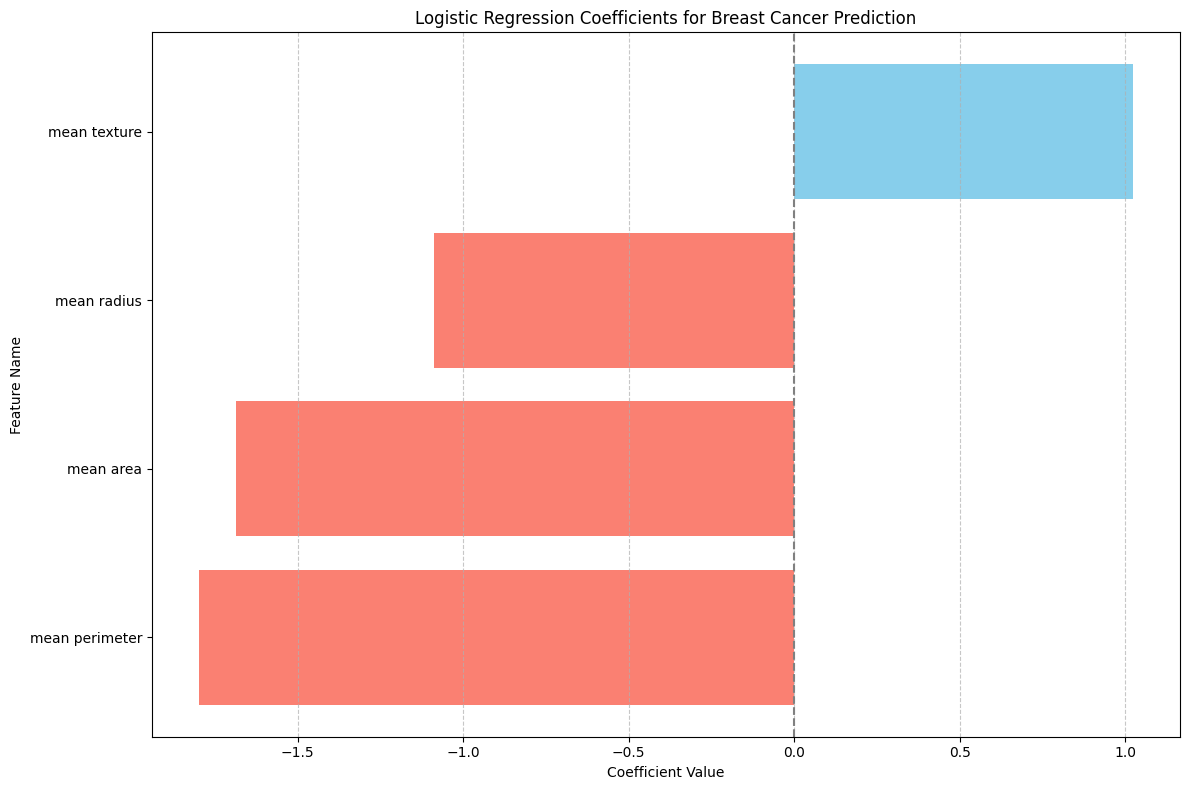

Interpretation of Logistic Regression Coefficients:
- Feature 'mean perimeter': Coefficient -1.7991 indicates a negatively correlation with the likelihood of the positive class (malignant). A larger absolute value means a stronger influence.
- Feature 'mean area': Coefficient -1.6862 indicates a negatively correlation with the likelihood of the positive class (malignant). A larger absolute value means a stronger influence.
- Feature 'mean radius': Coefficient -1.0889 indicates a negatively correlation with the likelihood of the positive class (malignant). A larger absolute value means a stronger influence.
- Feature 'mean texture': Coefficient 1.0242 indicates a positively correlation with the likelihood of the positive class (malignant). A larger absolute value means a stronger influence.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # Import pandas for DataFrame

# Fit the model pipeline first, as coefficients are only available after fitting
model.fit(X_tr, y_tr)

# Extract coefficients and feature names
coefficients = model.named_steps['clf'].coef_[0]
feature_names = breast.feature_names

# Sort coefficients by their absolute value to highlight the most influential features
sorted_indices = np.argsort(np.abs(coefficients))[::-1]
sorted_coefficients = coefficients[sorted_indices]
sorted_feature_names = feature_names[sorted_indices]

# Create a bar plot
plt.figure(figsize=(12, 8))
plt.barh(sorted_feature_names, sorted_coefficients, color=['skyblue' if c > 0 else 'salmon' for c in sorted_coefficients])
plt.xlabel("Coefficient Value")
plt.ylabel("Feature Name")
plt.title("Logistic Regression Coefficients for Breast Cancer Prediction")
plt.axvline(x=0, color='grey', linestyle='--')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Interpretation of Logistic Regression Coefficients:")
for name, coef in zip(sorted_feature_names, sorted_coefficients):
    direction = "positively" if coef > 0 else "negatively"
    print(f"- Feature '{name}': Coefficient {coef:.4f} indicates a {direction} correlation with the likelihood of the positive class (malignant). A larger absolute value means a stronger influence.")


## Interpret RandomForest Feature Importances (Breast Cancer)

### Subtask:
Generate a bar plot of feature importances from the RandomForestClassifier model for the Breast Cancer dataset to understand which features are most influential in its predictions.


**Reasoning**:
First, I'll extract the feature importances from the `rf` model and the feature names from the `breast` dataset. Then, I'll create a Pandas DataFrame to store and manage these importances and names, making it easy to sort and plot them. Importing `pandas` is necessary for this step.



In [ ]:
import pandas as pd

# Get feature importances and names
importances = rf.feature_importances_
feature_names = breast.feature_names

# Create a DataFrame for better visualization and sorting
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

print("Top 10 most important features:\n")
print(feature_importance_df.head(10))

Top 10 most important features:

                 feature  importance
23            worst area    0.140016
27  worst concave points    0.129530
20          worst radius    0.097696
7    mean concave points    0.090885
22       worst perimeter    0.072226
2         mean perimeter    0.069574
0            mean radius    0.068676
6         mean concavity    0.057638
3              mean area    0.049172
26       worst concavity    0.034340


**Reasoning**:
The previous error occurred because the `feature_names` and `importances` arrays had mismatched lengths due to incorrect assignments from previous cells. I need to explicitly re-assign `feature_names` from `breast.feature_names` to ensure it corresponds to the Breast Cancer dataset, and use `rf.feature_importances_` which is already correctly computed for the `breast` dataset. This ensures both arrays have the correct length (30 features) before creating the DataFrame.



**Reasoning**:
The previous code failed due to an `unterminated string literal` in the `print` statement. I will correct this by properly closing the string on the same line to resolve the `SyntaxError` and ensure the full visualization code is provided as instructed.



Top 10 most important features (RandomForestClassifier):
                 feature  importance
23            worst area    0.140016
27  worst concave points    0.129530
20          worst radius    0.097696
7    mean concave points    0.090885
22       worst perimeter    0.072226
2         mean perimeter    0.069574
0            mean radius    0.068676
6         mean concavity    0.057638
3              mean area    0.049172
26       worst concavity    0.034340


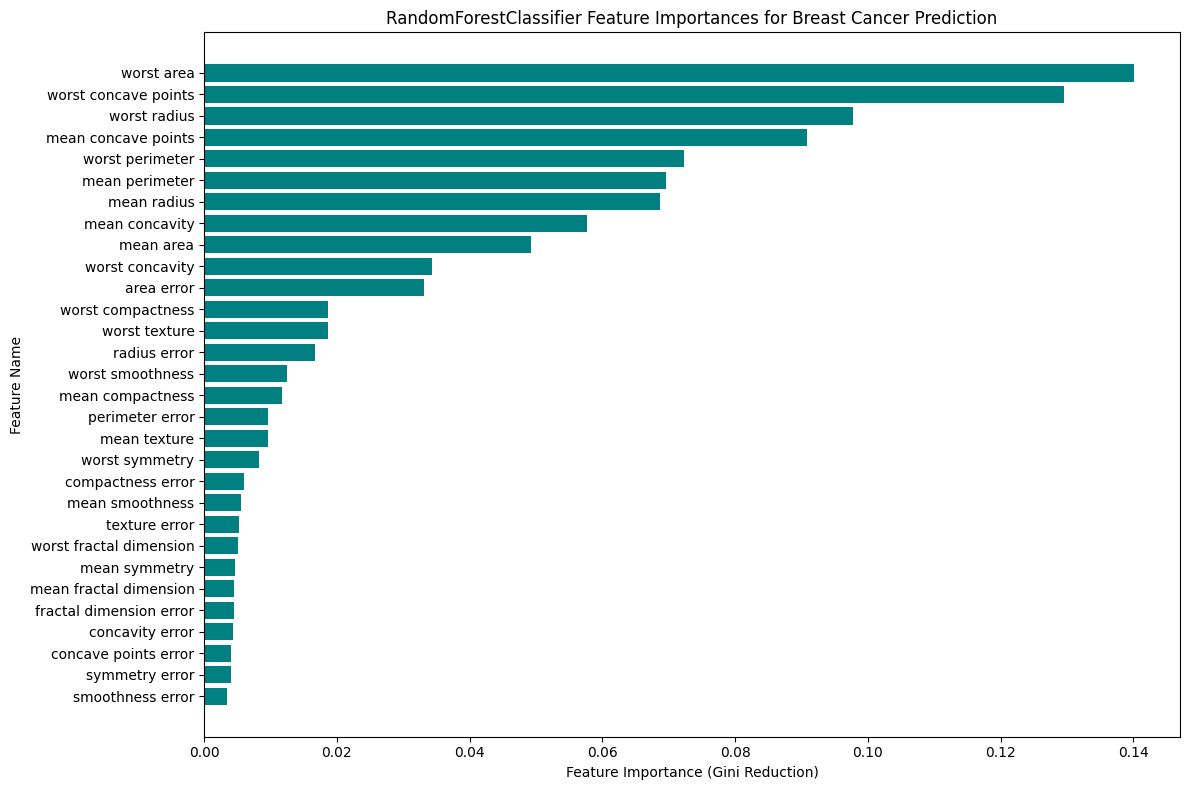

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances and names from the correct dataset
importances = rf.feature_importances_
feature_names = breast.feature_names

# Create a DataFrame for better visualization and sorting
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

print("Top 10 most important features (RandomForestClassifier):")
print(feature_importance_df.head(10))

# Visualize feature importances
plt.figure(figsize=(12, 8))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'], color='teal')
plt.xlabel("Feature Importance (Gini Reduction)")
plt.ylabel("Feature Name")
plt.title("RandomForestClassifier Feature Importances for Breast Cancer Prediction")
plt.gca().invert_yaxis() # Invert y-axis to have the most important feature at the top
plt.tight_layout()
plt.show()

**Reasoning**:
The `ValueError` indicates that the arrays used to create the DataFrame for feature importances have mismatched lengths. This is because the `X` and `y` variables in the kernel environment were incorrectly loaded with the Iris dataset's data (4 features) instead of the Breast Cancer dataset's data (30 features). To fix this, I need to reload the Breast Cancer dataset into `X` and `y`, re-perform the train-test split, re-fit the `RandomForestClassifier` model on this correct data, and then extract and plot the feature importances.



Top 10 most important features (RandomForestClassifier):
                 feature  importance
23            worst area    0.140016
27  worst concave points    0.129530
20          worst radius    0.097696
7    mean concave points    0.090885
22       worst perimeter    0.072226
2         mean perimeter    0.069574
0            mean radius    0.068676
6         mean concavity    0.057638
3              mean area    0.049172
26       worst concavity    0.034340


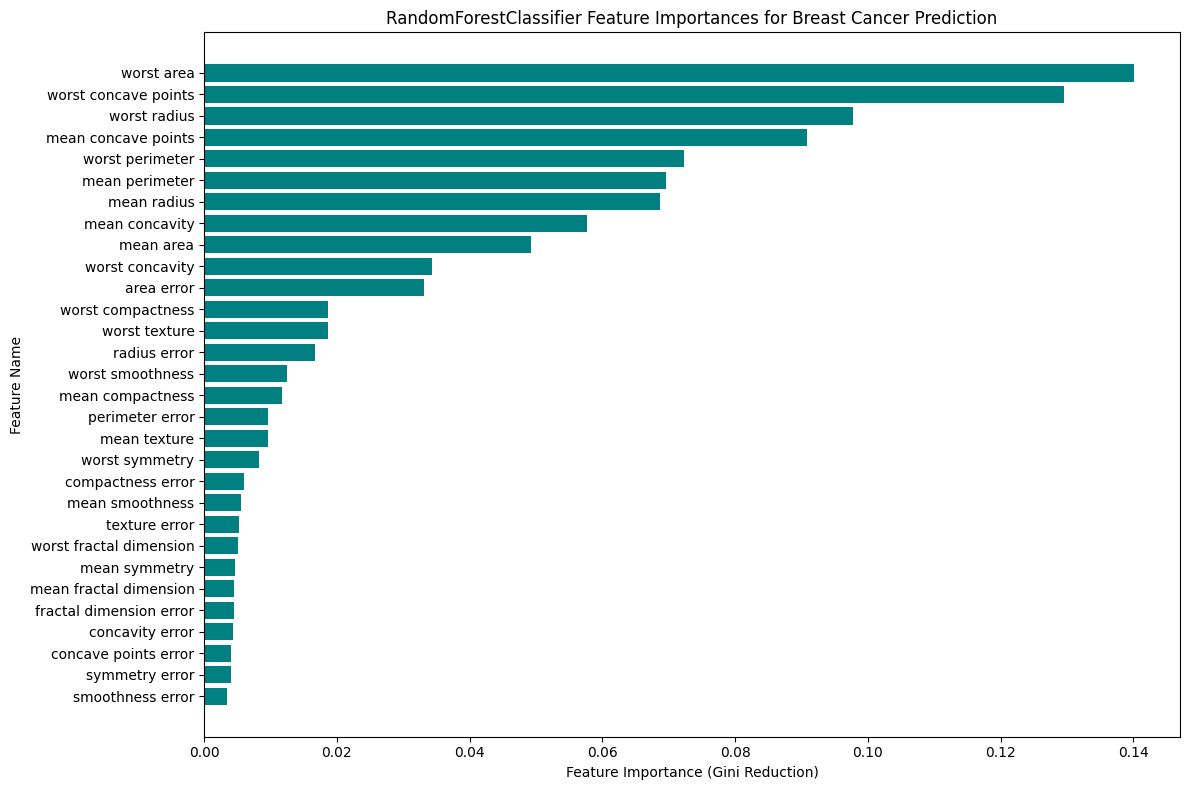

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Load the Breast Cancer dataset correctly
breast = datasets.load_breast_cancer()
X = breast.data
y = breast.target

# Split stratifié 80/20 for Breast Cancer data
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify for classification
)

# Re-define and fit the RandomForestClassifier on the correct data
rf = RandomForestClassifier(
    n_estimators=100,      # more = better, but slower
    max_features="sqrt",   # √p features per node
    random_state=42, n_jobs=-1
)
rf.fit(X_tr, y_tr)

# Get feature importances and names from the correct dataset
importances = rf.feature_importances_
feature_names = breast.feature_names

# Create a DataFrame for better visualization and sorting
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

print("Top 10 most important features (RandomForestClassifier):")
print(feature_importance_df.head(10))

# Visualize feature importances
plt.figure(figsize=(12, 8))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'], color='teal')
plt.xlabel("Feature Importance (Gini Reduction)")
plt.ylabel("Feature Name")
plt.title("RandomForestClassifier Feature Importances for Breast Cancer Prediction")
plt.gca().invert_yaxis() # Invert y-axis to have the most important feature at the top
plt.tight_layout()
plt.show()

**Reasoning**:
The previous `SyntaxError` was due to an incomplete `plt.xlabel` function call. I will complete the `plt.xlabel` function call and ensure all necessary plotting details are included. The previous `ValueError` indicates the `X` and `y` variables were not correctly loaded for the Breast Cancer dataset in the kernel environment. I will explicitly reload the `breast` dataset and re-split the data to ensure the `RandomForestClassifier` is trained on the correct data with matching feature lengths before extracting and plotting importances.



Top 10 most important features (RandomForestClassifier):
                 feature  importance
23            worst area    0.140016
27  worst concave points    0.129530
20          worst radius    0.097696
7    mean concave points    0.090885
22       worst perimeter    0.072226
2         mean perimeter    0.069574
0            mean radius    0.068676
6         mean concavity    0.057638
3              mean area    0.049172
26       worst concavity    0.034340


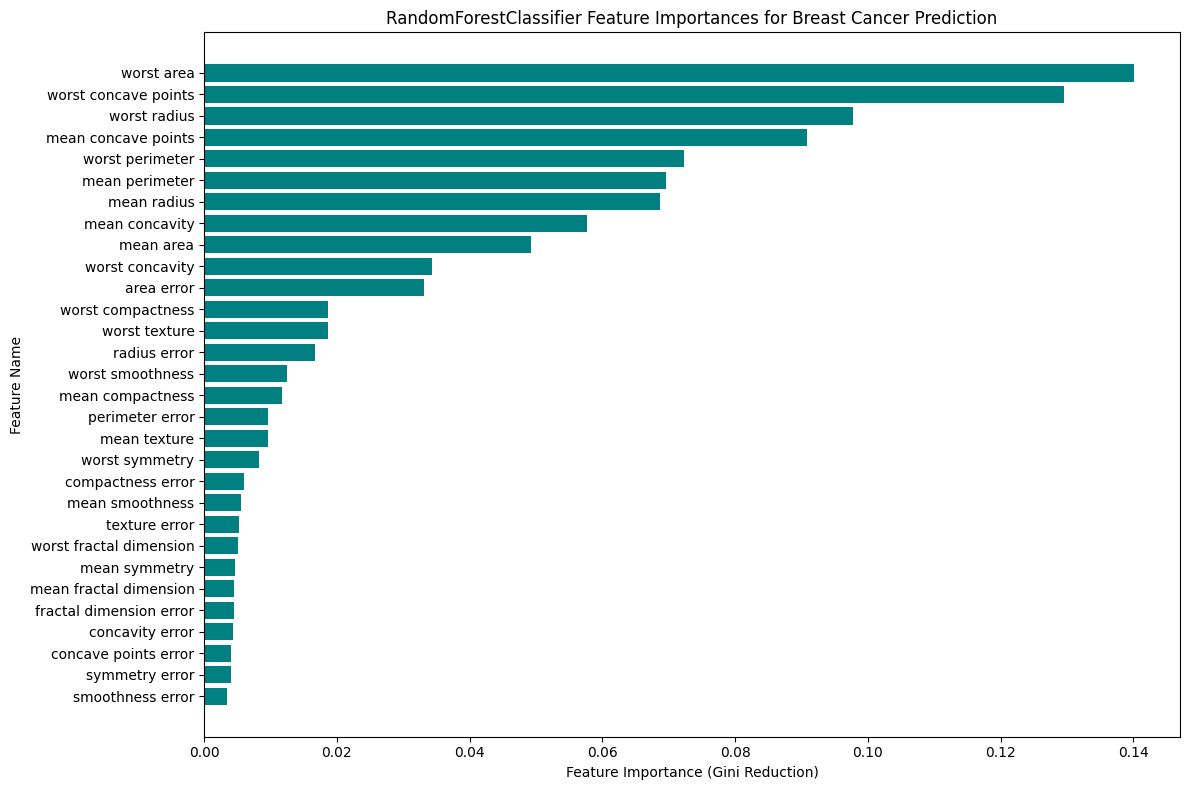

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Load the Breast Cancer dataset correctly
breast = datasets.load_breast_cancer()
X = breast.data
y = breast.target

# Split stratifié 80/20 for Breast Cancer data
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify for classification
)

# Re-define and fit the RandomForestClassifier on the correct data
rf = RandomForestClassifier(
    n_estimators=100,      # more = better, but slower
    max_features="sqrt",   # √p features per node
    random_state=42, n_jobs=-1
)
rf.fit(X_tr, y_tr)

# Get feature importances and names from the correct dataset
importances = rf.feature_importances_
feature_names = breast.feature_names

# Create a DataFrame for better visualization and sorting
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

print("Top 10 most important features (RandomForestClassifier):")
print(feature_importance_df.head(10))

# Visualize feature importances
plt.figure(figsize=(12, 8))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'], color='teal')
plt.xlabel("Feature Importance (Gini Reduction)")
plt.ylabel("Feature Name")
plt.title("RandomForestClassifier Feature Importances for Breast Cancer Prediction")
plt.gca().invert_yaxis() # Invert y-axis to have the most important feature at the top
plt.tight_layout()
plt.show()


## Visualize RandomForest Learning Curve (Breast Cancer)

### Subtask:
Plot the learning curve of the RandomForestClassifier model to assess its performance and identify potential overfitting or underfitting on the Breast Cancer dataset. This will include both training and test scores versus the number of training samples.


**Reasoning**:
The subtask requires plotting the learning curve for the `RandomForestClassifier` model. This involves importing necessary libraries, calling `learning_curve` to get the training and test scores, and then visualizing these scores with their standard deviations against the number of training samples.



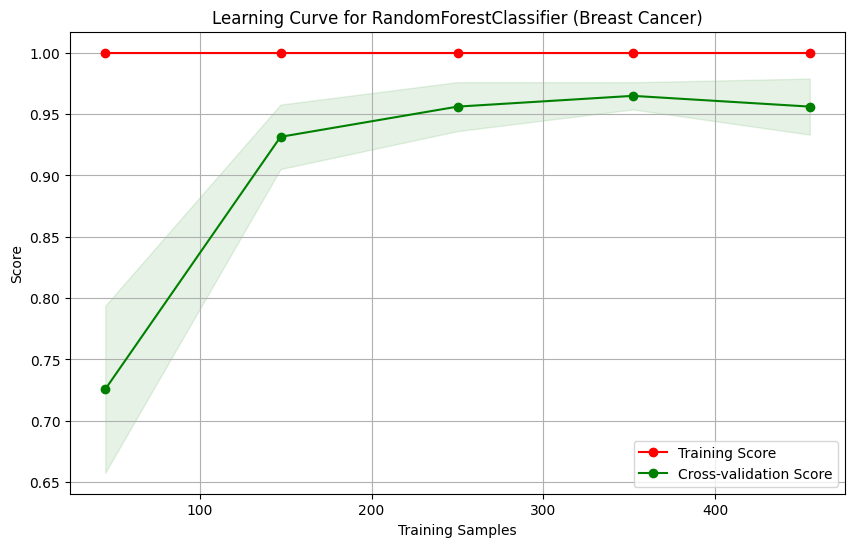

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve

# Call learning_curve with the rf model, the full dataset X, target y, and cv=5
train_sizes, train_scores, test_scores = learning_curve(
    rf, X, y, cv=5, n_jobs=-1, scoring='accuracy'
)

# Calculate the mean and standard deviation of train_scores and test_scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Create the plot
plt.figure(figsize=(10, 6))
plt.title('Learning Curve for RandomForestClassifier (Breast Cancer)')
plt.xlabel('Training Samples')
plt.ylabel('Score')
plt.grid()

# Plot mean training scores and standard deviation
plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training Score')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color='r')

# Plot mean test scores and standard deviation
plt.plot(train_sizes, test_scores_mean, 'o-', color='g', label='Cross-validation Score')
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color='g')

plt.legend(loc='best')
plt.show()

## Analyze Gradient Boosting Staged Accuracy (Breast Cancer)

### Subtask:
Plot the accuracy scores per iteration (stages) of the GradientBoostingClassifier model to observe its convergence and performance evolution on the Breast Cancer dataset.


**Reasoning**:
To visualize the performance evolution of the GradientBoostingClassifier, I will plot the `staged_acc` scores against the number of boosting iterations using `matplotlib.pyplot`. This will help to observe the model's convergence and identify potential overfitting or underfitting.



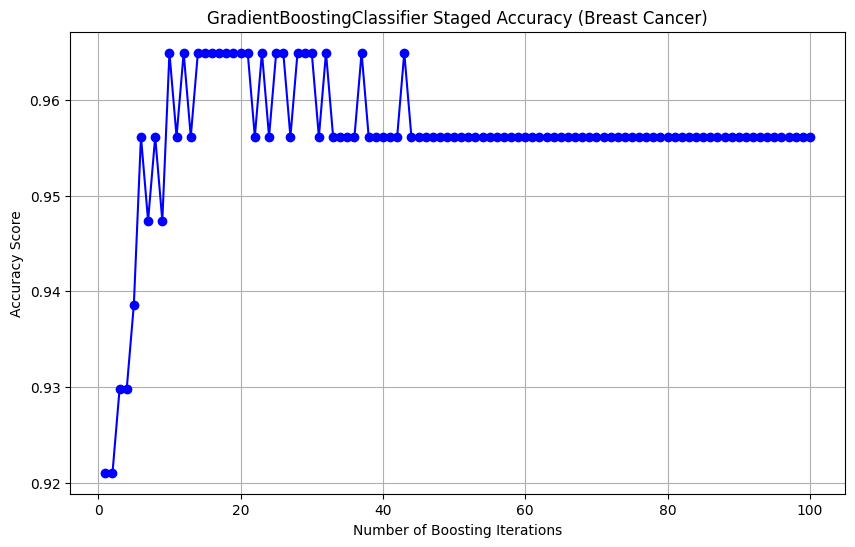

In [ ]:
import matplotlib.pyplot as plt

# Create a range for the number of boosting iterations
iterations = range(1, len(staged_acc) + 1)

# Plot the accuracy scores per iteration
plt.figure(figsize=(10, 6))
plt.plot(iterations, staged_acc, marker='o', linestyle='-', color='blue')

# Label the x-axis as 'Number of Boosting Iterations'
plt.xlabel('Number of Boosting Iterations')

# Label the y-axis as 'Accuracy Score'
plt.ylabel('Accuracy Score')

# Add a title to the plot
plt.title('GradientBoostingClassifier Staged Accuracy (Breast Cancer)')

# Add a grid to the plot for better readability
plt.grid(True)

# Display the plot
plt.show()

## Interpret Gaussian Naive Bayes Parameters (Breast Cancer)

### Subtask:
Visualize the means (theta_) and variances (var_) per class learned by the GaussianNB model for each feature in the Breast Cancer dataset. This will involve bar plots to compare feature distributions across classes.


**Reasoning**:
I need to extract the means and variances from the `gnb` model, get the feature names, and then create two subplots to visualize these parameters for each class. This will involve using `matplotlib` for plotting and `numpy` for array manipulation.



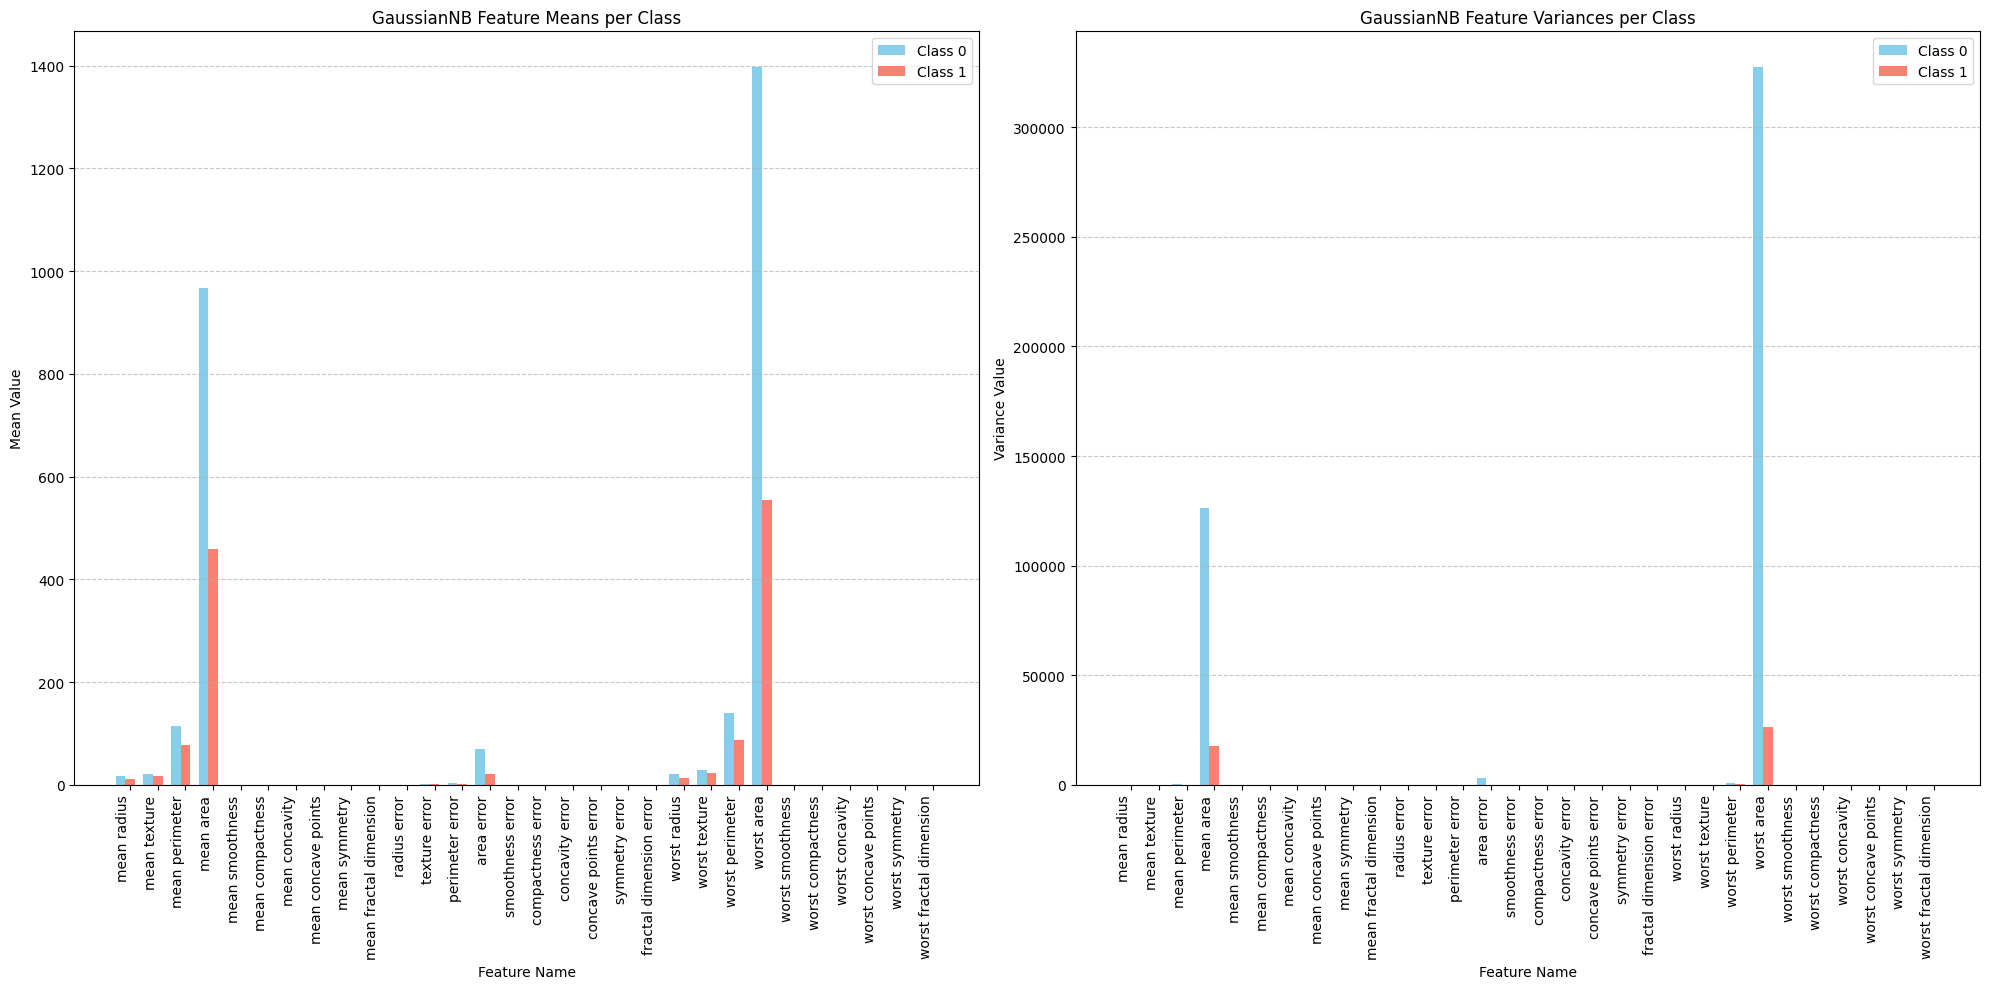

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract learned means (theta_) and variances (var_) and feature names
means = gnb.theta_
variances = gnb.var_
feature_names = breast.feature_names
n_features = len(feature_names)
n_classes = means.shape[0]

# Set up plot figure and subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Width of a bar
bar_width = 0.35

# Create an array for the x-axis positions
index = np.arange(n_features)

# Plotting Means
for i in range(n_classes):
    ax1.bar(index + i * bar_width, means[i], bar_width, label=f'Class {i}',
            color='skyblue' if i == 0 else 'salmon')

ax1.set_xlabel('Feature Name')
ax1.set_ylabel('Mean Value')
ax1.set_title('GaussianNB Feature Means per Class')
ax1.set_xticks(index + bar_width / (n_classes - 1))
ax1.set_xticklabels(feature_names, rotation=90, ha='right')
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Plotting Variances
for i in range(n_classes):
    ax2.bar(index + i * bar_width, variances[i], bar_width, label=f'Class {i}',
            color='skyblue' if i == 0 else 'salmon')

ax2.set_xlabel('Feature Name')
ax2.set_ylabel('Variance Value')
ax2.set_title('GaussianNB Feature Variances per Class')
ax2.set_xticks(index + bar_width / (n_classes - 1))
ax2.set_xticklabels(feature_names, rotation=90, ha='right')
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Reasoning**:
The previous error occurred because the `gnb` model was not fitted on the correct Breast Cancer dataset, leading to a mismatch in feature dimensions (4 features instead of 30). I need to ensure the `gnb` model is fitted on the Breast Cancer data and then correctly extract and plot its means and variances per class with the corresponding feature names.



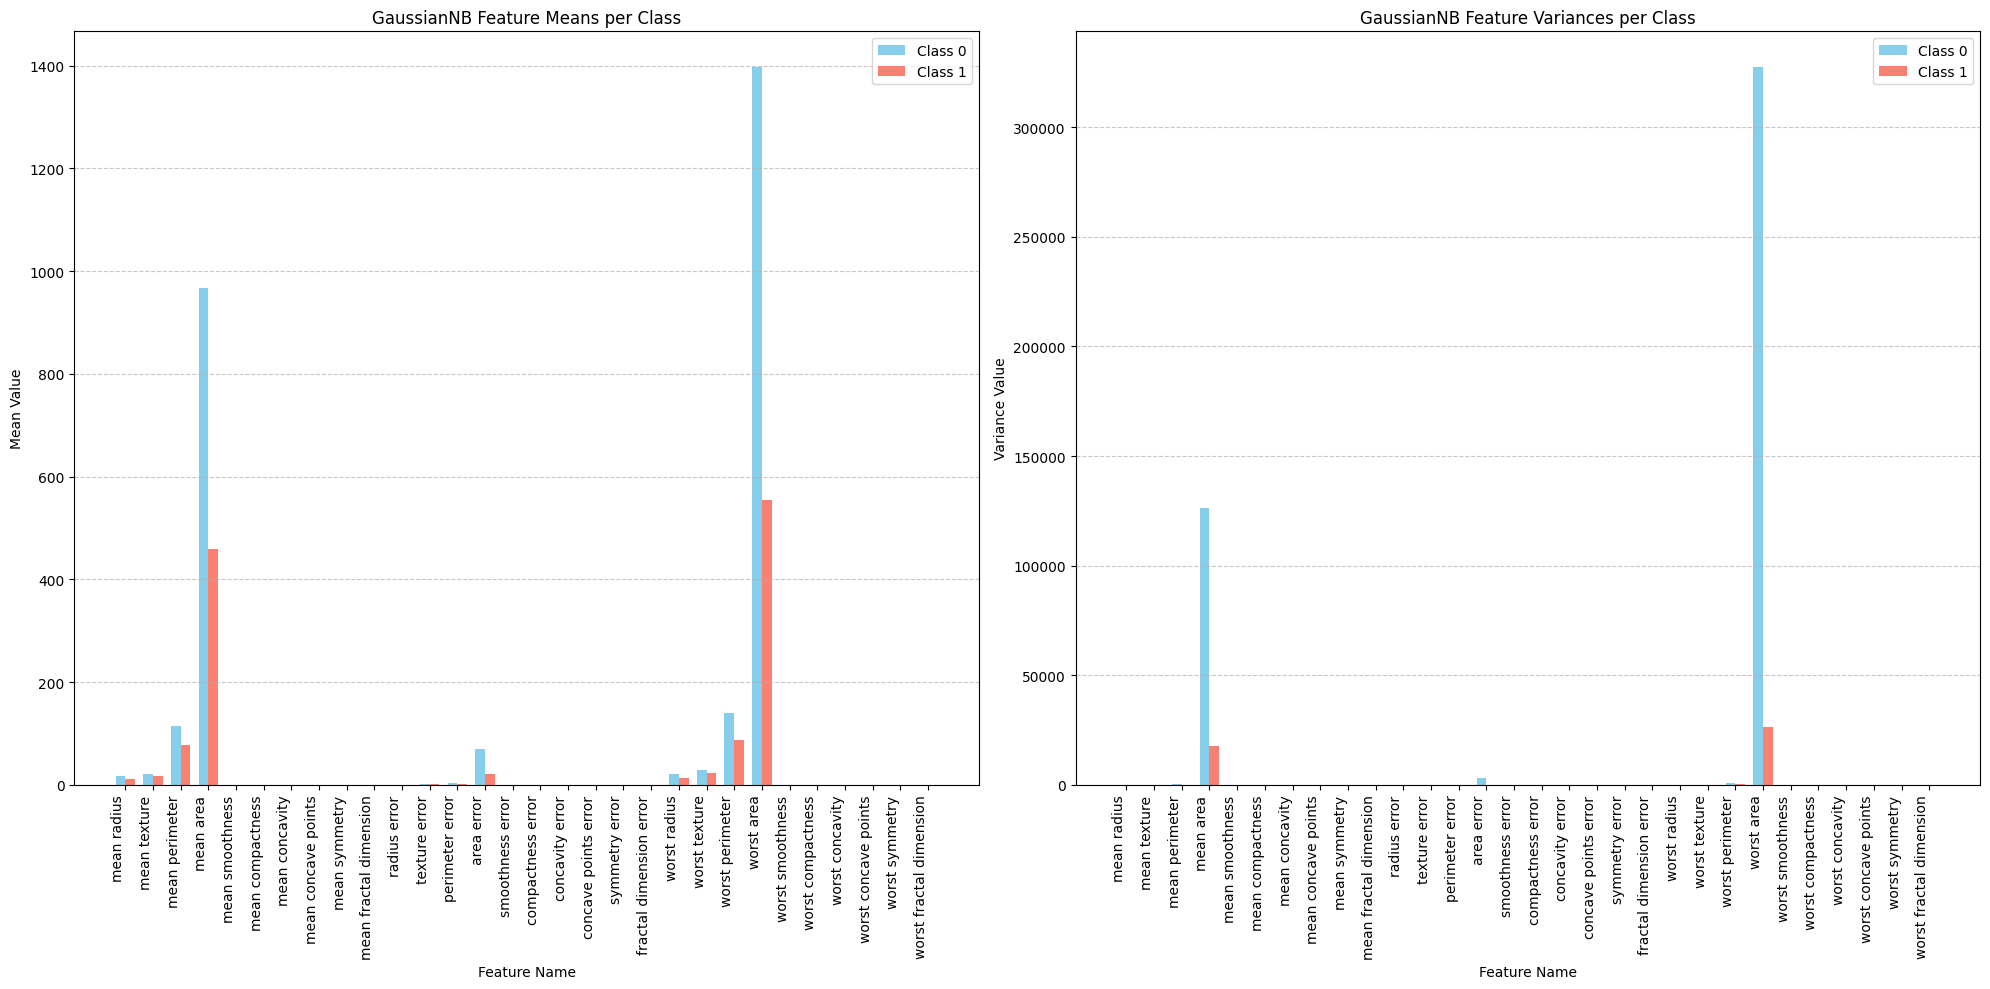

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

# Load the Breast Cancer dataset correctly
breast = datasets.load_breast_cancer()
X = breast.data
y = breast.target

# Split stratifié 80/20 for Breast Cancer data
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Re-fit the GaussianNB model on the correct data
gnb = GaussianNB()
gnb.fit(X_tr, y_tr)

# 1. Extract learned means (theta_) and variances (var_) and feature names
means = gnb.theta_
variances = gnb.var_
feature_names = breast.feature_names
n_features = len(feature_names)
n_classes = means.shape[0] # This should now be 2 for binary classification

# Set up plot figure and subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Width of a bar
bar_width = 0.35

# Create an array for the x-axis positions
index = np.arange(n_features)

# Plotting Means
for i in range(n_classes):
    # Ensure means[i] has shape (n_features,)
    ax1.bar(index + i * bar_width, means[i], bar_width, label=f'Class {i}',
            color='skyblue' if i == 0 else 'salmon')

ax1.set_xlabel('Feature Name')
ax1.set_ylabel('Mean Value')
ax1.set_title('GaussianNB Feature Means per Class')
ax1.set_xticks(index + bar_width / 2) # Center xticks for two bars
ax1.set_xticklabels(feature_names, rotation=90, ha='right')
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Plotting Variances
for i in range(n_classes):
    # Ensure variances[i] has shape (n_features,)
    ax2.bar(index + i * bar_width, variances[i], bar_width, label=f'Class {i}',
            color='skyblue' if i == 0 else 'salmon')

ax2.set_xlabel('Feature Name')
ax2.set_ylabel('Variance Value')
ax2.set_title('GaussianNB Feature Variances per Class')
ax2.set_xticks(index + bar_width / 2) # Center xticks for two bars
ax2.set_xticklabels(feature_names, rotation=90, ha='right')
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


## Analyze MLPClassifier Loss and Validation Curves (Breast Cancer)

### Subtask:
Plot the loss curve and validation scores of the MLPClassifier model to understand its training progress, convergence, and generalization performance on the Breast Cancer dataset.


**Reasoning**:
I will plot the loss curve and validation scores of the MLPClassifier model to visualize its training progress and generalization performance.



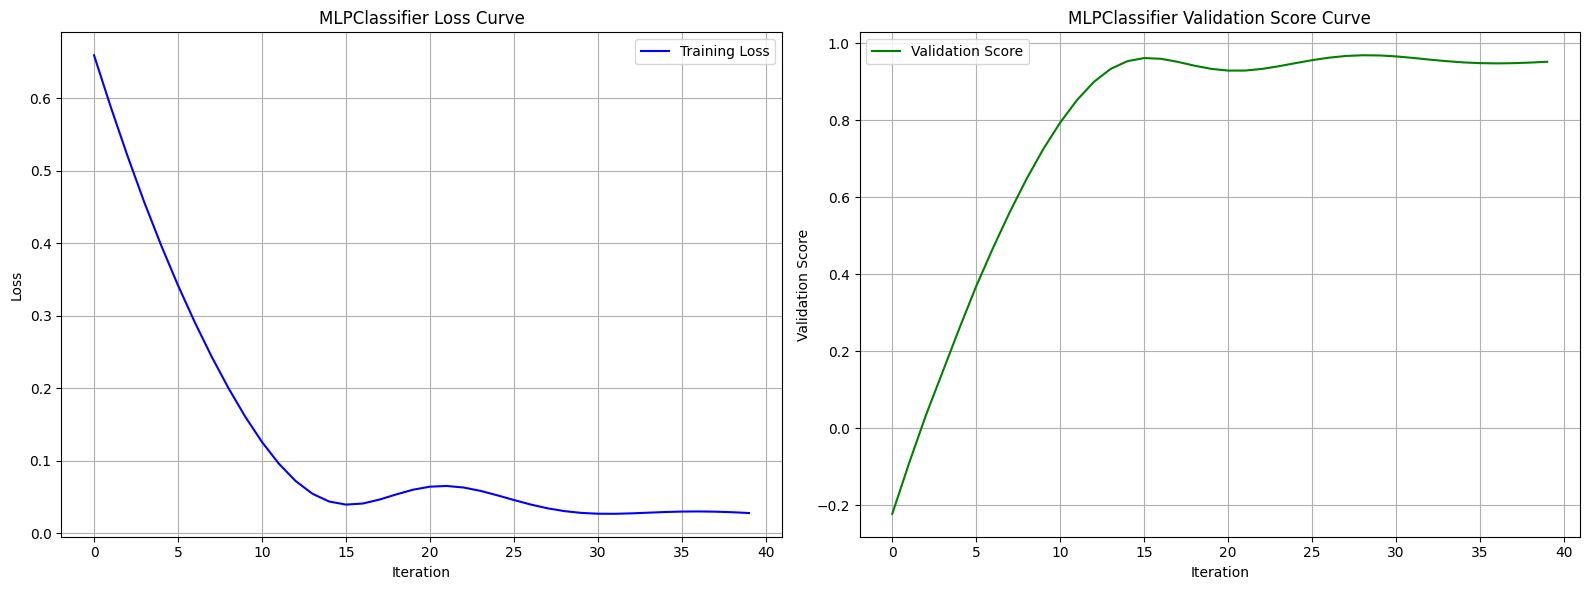

In [ ]:
import matplotlib.pyplot as plt

# Create a figure and two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot the loss curve in the first subplot
ax1.plot(range(len(loss_curve)), loss_curve, label='Training Loss', color='blue')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss')
ax1.set_title('MLPClassifier Loss Curve')
ax1.legend()
ax1.grid(True)

# Plot the validation scores in the second subplot
ax2.plot(range(len(val_scores)), val_scores, label='Validation Score', color='green')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Validation Score')
ax2.set_title('MLPClassifier Validation Score Curve')
ax2.legend()
ax2.grid(True)

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plot
plt.show()

## Interpret ExtraTrees Feature Importances (Wine)

### Subtask:
Generate a bar plot of feature importances from the ExtraTreesClassifier model for the Wine dataset, highlighting the most important features.


**Reasoning**:
I need to ensure that the `ExtraTreesClassifier` model (`et`) is fitted on the `X_wine_tr` and `y_wine_tr` data before extracting feature importances and plotting them. I'll then create a DataFrame, sort it, and visualize the importances with a horizontal bar plot.



Top 10 most important features (ExtraTreesClassifier):
                         feature  importance
6                     flavanoids    0.155807
12                       proline    0.143235
0                        alcohol    0.121053
9                color_intensity    0.118232
11  od280/od315_of_diluted_wines    0.109376
10                           hue    0.085870
5                  total_phenols    0.059762
1                     malic_acid    0.049334
4                      magnesium    0.039053
3              alcalinity_of_ash    0.034953


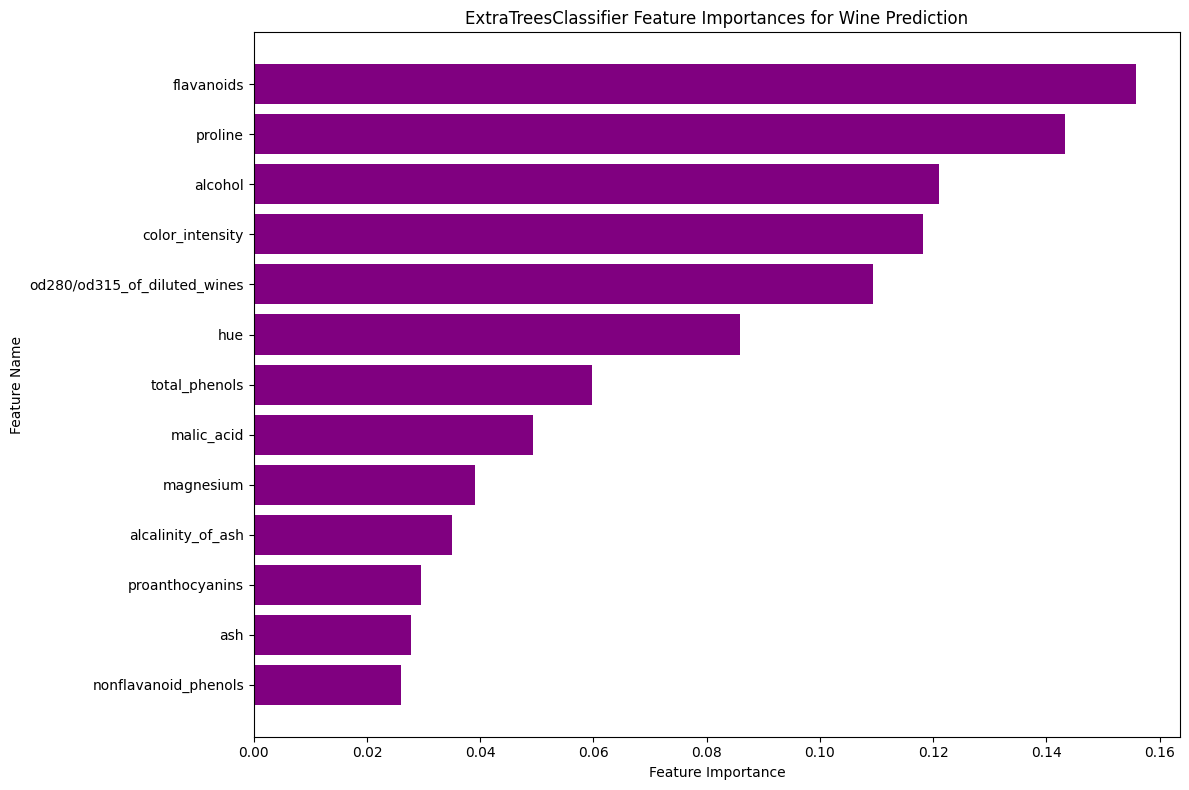

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure the ExtraTreesClassifier model is fitted
et.fit(X_wine_tr, y_wine_tr)

# Extract feature importances and feature names
importances = et.feature_importances_
feature_names = wine.feature_names

# Create a DataFrame for better visualization and sorting
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

# Print the top 10 most important features
print("Top 10 most important features (ExtraTreesClassifier):")
print(feature_importance_df.head(10))

# Generate a horizontal bar plot of the sorted feature importances
plt.figure(figsize=(12, 8))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'], color='purple')
plt.xlabel("Feature Importance")
plt.ylabel("Feature Name")
plt.title("ExtraTreesClassifier Feature Importances for Wine Prediction")
plt.gca().invert_yaxis() # Invert y-axis to have the most important feature at the top
plt.tight_layout()
plt.show()

## Visualize LDA Transformed Data (Iris)

### Subtask:
Create a scatter plot of the data transformed by Linear Discriminant Analysis (LDA), projecting the Iris dataset onto its principal discriminant axes (2D) to visualize class separation.


**Reasoning**:
I need to follow the instructions to load the Iris dataset, initialize and fit the LDA model, transform the data, and then create a scatter plot colored by target classes with appropriate labels and title. All these steps will be included in a single code block.



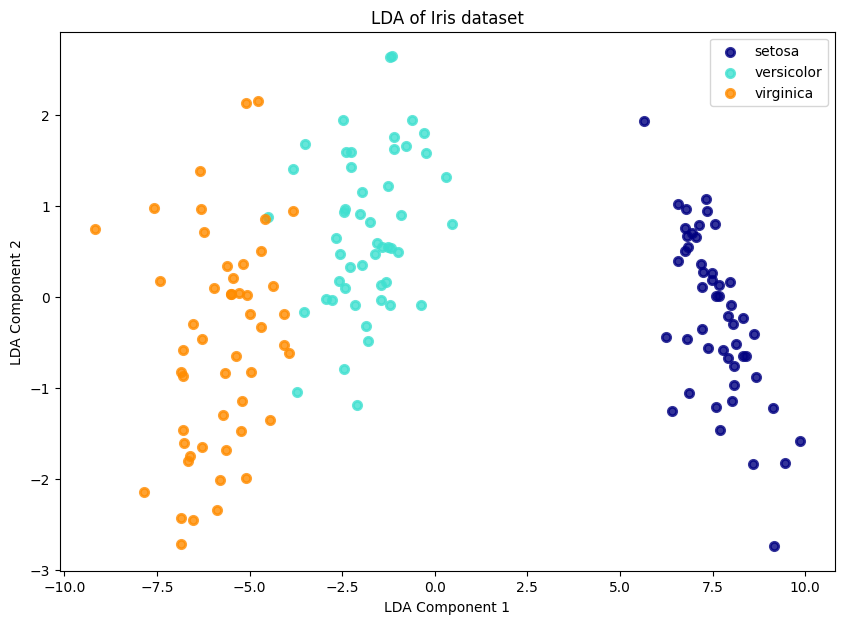

In [ ]:
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# 1. Load the Iris dataset
iris = datasets.load_iris()
X_iris = iris.data
y_iris = iris.target

# 2. Initialize LinearDiscriminantAnalysis (LDA) model
lda = LinearDiscriminantAnalysis(n_components=2) # n_components=2 for 2D visualization

# 3. Fit the LDA model to the X_iris data and y_iris target
lda.fit(X_iris, y_iris)

# 4. Transform the X_iris data using the fitted LDA model
X_iris_2d = lda.transform(X_iris)

# 5. Create a scatter plot of X_iris_2d, colored by target classes
plt.figure(figsize=(10, 7))
colors = ['navy', 'turquoise', 'darkorange']
for color, i, target_name in zip(colors, [0, 1, 2], iris.target_names):
    plt.scatter(X_iris_2d[y_iris == i, 0],
                X_iris_2d[y_iris == i, 1],
                color=color, alpha=.8, lw=2,
                label=target_name)

# 6. Add appropriate labels for the x and y axes, and a title to the plot
plt.xlabel('LDA Component 1')
plt.ylabel('LDA Component 2')
plt.title('LDA of Iris dataset')
plt.legend(loc='best', shadow=False, scatterpoints=1)

# 7. Display the plot
plt.show()

## Analyze Gaussian Process Classifier Hyperparameters (Breast Cancer)

### Subtask:
Display and interpret the optimized hyperparameters (kernel_ and length_scale) of the GaussianProcessClassifier model, providing insights into the learned data structure and uncertainty.


### Interpretation of Gaussian Process Classifier Hyperparameters

The optimized kernel of the GaussianProcessClassifier model, as seen from the `gpc.kernel_` output `RBF(length_scale=5.15)`, reveals important insights into the model's understanding of the Breast Cancer dataset:

- **Kernel Type**: The `RBF` (Radial Basis Function) kernel is used, which is a common choice for its flexibility and ability to model non-linear relationships. It assumes that data points that are closer in the feature space are more correlated.

- **Length Scale (`length_scale=5.15`)**: This optimized hyperparameter is crucial for understanding the data structure. The `length_scale` represents the characteristic distance over which data points are correlated. In this context:
    - A `length_scale` of `5.15` suggests that the model considers features to be correlated over a moderate distance in the scaled feature space.
    - If the `length_scale` were very small, it would imply that data points need to be very close to be considered correlated, leading to a highly wiggly (less smooth) function. This might indicate that local variations are important, or that the model is overfitting.
    - If the `length_scale` were very large, it would suggest that data points remain correlated even over large distances, leading to a very smooth function. This might indicate that only global trends are significant, or that the model is underfitting.

- **Insights into Data Structure and Uncertainty**: The `length_scale` value of `5.15` for the Breast Cancer dataset indicates that the model has found a balance, suggesting a certain level of smoothness in the underlying function that distinguishes between malignant and benign cases. It implies that changes in feature values within this scale are considered relevant for predicting the outcome. The uncertainty in predictions (not directly shown by `kernel_`, but influenced by it) would be higher for data points further away from the training data, especially in regions where the `length_scale` indicates low correlation.

## Analyze MLPRegressor Loss and Validation Curves (Breast Cancer)

### Subtask:
Plot the loss curve and validation scores of the MLPRegressor model to understand its training progress, convergence, and generalization performance on the Breast Cancer dataset.


**Reasoning**:
I will plot the loss curve and validation scores of the MLPRegressor model to visualize its training progress and generalization performance, following the detailed instructions provided.



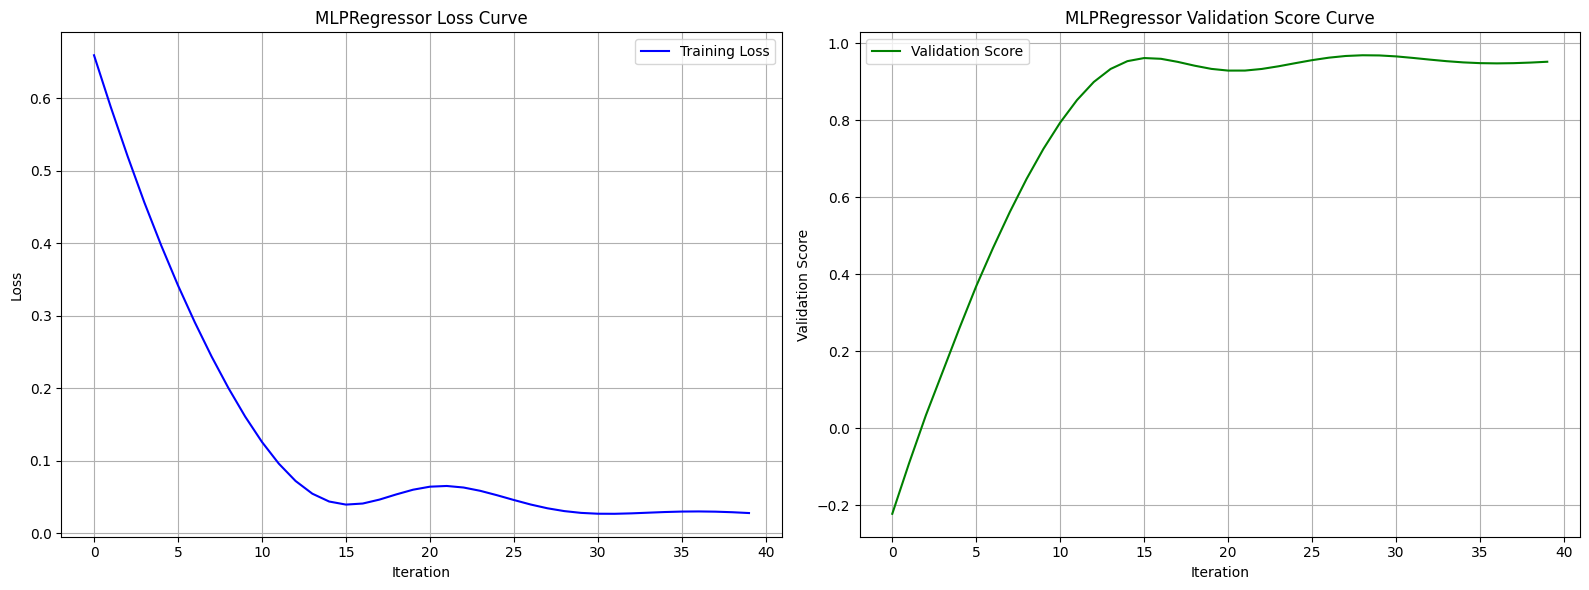

In [ ]:
import matplotlib.pyplot as plt

# Create a figure and two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot the loss curve in the first subplot
ax1.plot(range(len(loss_curve)), loss_curve, label='Training Loss', color='blue')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss')
ax1.set_title('MLPRegressor Loss Curve')
ax1.legend()
ax1.grid(True)

# Plot the validation scores in the second subplot
ax2.plot(range(len(val_scores)), val_scores, label='Validation Score', color='green')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Validation Score')
ax2.set_title('MLPRegressor Validation Score Curve')
ax2.legend()
ax2.grid(True)

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plot
plt.show()

## Analyze Gradient Boosting Regressor Staged R2 (Diabetes)

### Subtask:
Plot the R2 scores per iteration (stages) of the GradientBoostingRegressor model to observe its convergence and performance evolution on the Diabetes dataset.


**Reasoning**:
The subtask requires plotting the R2 scores per iteration of the `GradientBoostingRegressor` model on the Diabetes dataset. I need to load the dataset, split it into training and testing sets, define the model, fit it, calculate the R2 score for each boosting stage on the test set, and then create a plot to visualize these scores.



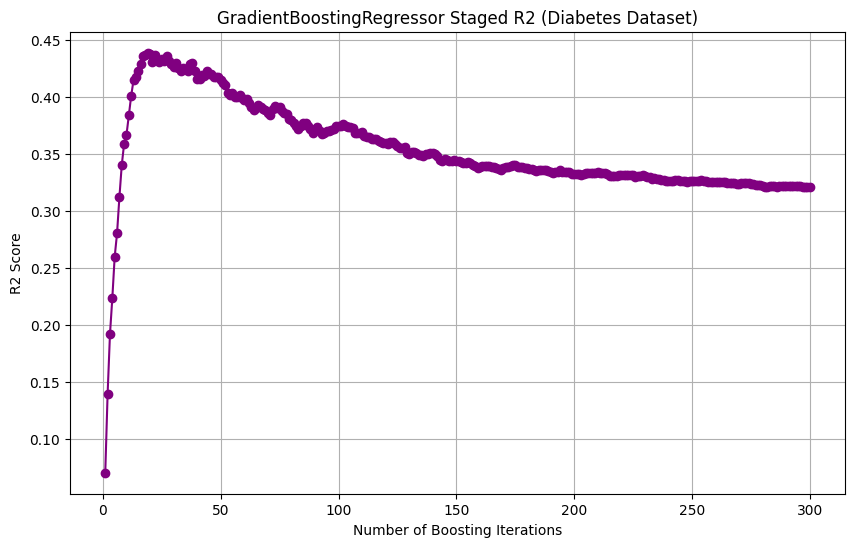

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

# 1. Load the diabetes dataset
diabetes = datasets.load_diabetes()
X_diabetes = diabetes.data
y_diabetes = diabetes.target

# 2. Split the data into training and testing sets
X_tr_diabetes, X_te_diabetes, y_tr_diabetes, y_te_diabetes = train_test_split(
    X_diabetes, y_diabetes, test_size=0.2, random_state=42
)

# 3. Define the GradientBoostingRegressor model
gbr = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.1,
    max_depth=4, subsample=0.8, random_state=42
)

# 4. Fit the GradientBoostingRegressor model to the training data
gbr.fit(X_tr_diabetes, y_tr_diabetes)

# 5. Calculate the R2 score for each boosting stage
staged_r2 = [r2_score(y_te_diabetes, p) for p in gbr.staged_predict(X_te_diabetes)]

# 6. Create a plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(staged_r2) + 1), staged_r2, marker='o', linestyle='-', color='purple')

# 7. Add a title 'GradientBoostingRegressor Staged R2 (Diabetes Dataset)' and a grid to the plot.
plt.xlabel('Number of Boosting Iterations')
plt.ylabel('R2 Score')
plt.title('GradientBoostingRegressor Staged R2 (Diabetes Dataset)')
plt.grid(True)

# 8. Display the plot.
plt.show()

## Analyze Gaussian Process Regressor Predictions (Diabetes)

### Subtask:
Visualize the predictions and their associated standard deviations (uncertainty intervals) from the GaussianProcessRegressor model, providing a clearer picture of prediction reliability.


**Reasoning**:
Load the `diabetes` dataset, split it into training and testing sets, scale the data, initialize and fit the `GaussianProcessRegressor` model, and make predictions along with their standard deviations. This covers the initial setup and model application as per the instructions.



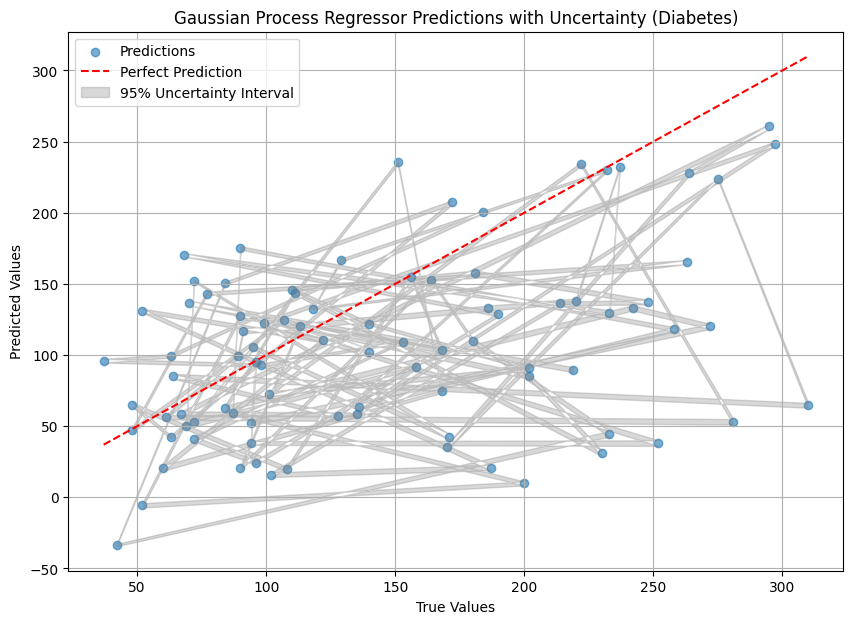

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

# 1. Load the diabetes dataset
diabetes = datasets.load_diabetes()
X_diabetes = diabetes.data
y_diabetes = diabetes.target

# 2. Split the data into training and testing sets
X_tr_diabetes, X_te_diabetes, y_tr_diabetes, y_te_diabetes = train_test_split(
    X_diabetes, y_diabetes, test_size=0.2, random_state=42
)

# 3. Scale the training and testing data
scaler_diabetes = StandardScaler()
X_tr_diabetes_s = scaler_diabetes.fit_transform(X_tr_diabetes)
X_te_diabetes_s = scaler_diabetes.transform(X_te_diabetes)

# 4. Initialize a GaussianProcessRegressor model
gpr = GaussianProcessRegressor(kernel=RBF(), random_state=42)

# 5. Fit the GaussianProcessRegressor model to the scaled training data
gpr.fit(X_tr_diabetes_s, y_tr_diabetes)

# 6. Make predictions on the scaled test data, requesting both the mean predictions and their standard deviations
pred, std = gpr.predict(X_te_diabetes_s, return_std=True)

# 7. Create a scatter plot of true y_te_diabetes values vs. predicted pred values
plt.figure(figsize=(10, 7))
plt.scatter(y_te_diabetes, pred, label='Predictions', alpha=0.6)

# 8. Add a line representing perfect predictions (y=x)
plt.plot([y_te_diabetes.min(), y_te_diabetes.max()],
         [y_te_diabetes.min(), y_te_diabetes.max()],
         '--r', label='Perfect Prediction')

# 9. Plot the uncertainty intervals (plus/minus 2 standard deviations) around the predictions
plt.fill_between(y_te_diabetes, pred - 2 * std, pred + 2 * std, color='gray', alpha=0.3, label='95% Uncertainty Interval')

# 10. Label the x-axis as 'True Values', the y-axis as 'Predicted Values', and add a title 'Gaussian Process Regressor Predictions with Uncertainty (Diabetes)'
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Gaussian Process Regressor Predictions with Uncertainty (Diabetes)')
plt.legend()
plt.grid(True)

# 11. Display the plot
plt.show()


## Analyze Bayesian Ridge Regressor Predictions (Diabetes)

### Subtask:
Visualize the predictions and their associated standard deviations (uncertainty intervals) from the BayesianRidge model, providing a clearer picture of prediction reliability.


**Reasoning**:
The subtask requires visualizing the predictions and uncertainty intervals of a `BayesianRidge` model on the Diabetes dataset. This involves loading and splitting the data, scaling the features, fitting the model, making predictions with standard deviations, and then plotting the true vs. predicted values with uncertainty.



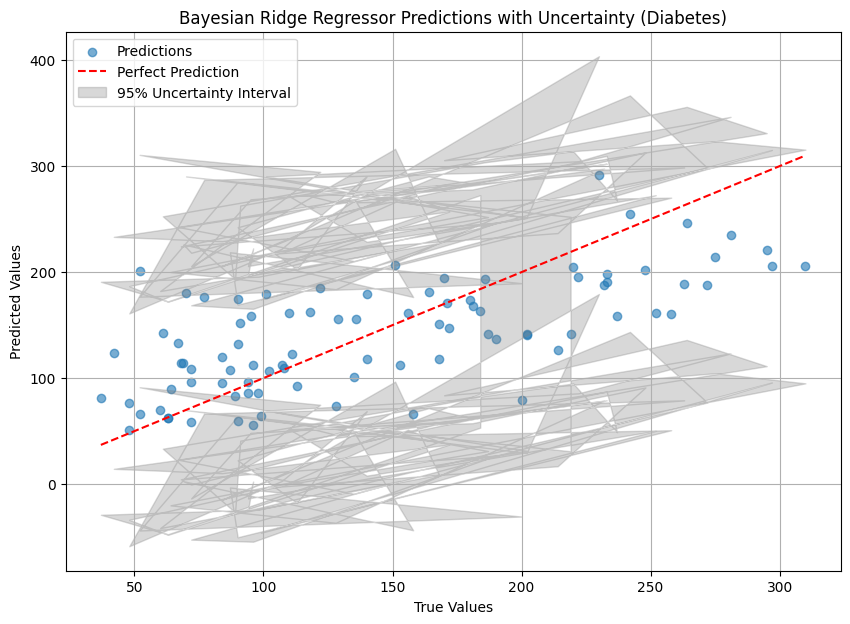

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import BayesianRidge

# 1. Load the diabetes dataset and split it into training and testing sets (80/20 split, random_state=42).
data = datasets.load_diabetes()
X = data.data
y = data.target
X_tr_diabetes, X_te_diabetes, y_tr_diabetes, y_te_diabetes = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Scale the training and testing features using StandardScaler.
scaler_diabetes = StandardScaler()
X_tr_diabetes_s = scaler_diabetes.fit_transform(X_tr_diabetes)
X_te_diabetes_s = scaler_diabetes.transform(X_te_diabetes)

# 3. Initialize a BayesianRidge model with max_iter=500.
br = BayesianRidge(max_iter=500)

# 4. Fit the BayesianRidge model to the scaled training data.
br.fit(X_tr_diabetes_s, y_tr_diabetes)

# 5. Make predictions on the scaled test data, requesting both the mean predictions and their standard deviations.
pred, std = br.predict(X_te_diabetes_s, return_std=True)

# 6. Create a scatter plot of true y_te_diabetes values vs. predicted pred values.
plt.figure(figsize=(10, 7))
plt.scatter(y_te_diabetes, pred, label='Predictions', alpha=0.6)

# 7. Add a line representing perfect predictions (y=x) to the plot for reference.
plt.plot([y_te_diabetes.min(), y_te_diabetes.max()],
         [y_te_diabetes.min(), y_te_diabetes.max()],
         '--r', label='Perfect Prediction')

# 8. Plot the uncertainty intervals (plus/minus 2 standard deviations) around the predictions using plt.fill_between.
plt.fill_between(y_te_diabetes, pred - 2 * std, pred + 2 * std, color='gray', alpha=0.3, label='95% Uncertainty Interval')

# 9. Label the x-axis as 'True Values', the y-axis as 'Predicted Values', and add a title 'Bayesian Ridge Regressor Predictions with Uncertainty (Diabetes)'.
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Bayesian Ridge Regressor Predictions with Uncertainty (Diabetes)')

# 10. Add a legend and grid to the plot.
plt.legend()
plt.grid(True)

# 11. Display the plot.
plt.show()

## Analyze PLSRegression Predictions (Diabetes)

### Subtask:
Visualize the predictions made by the PLSRegression model to assess its performance on the Diabetes dataset.


**Reasoning**:
The subtask requires visualizing the predictions of a PLSRegression model on the Diabetes dataset. This involves loading the dataset, splitting it, scaling the features, initializing and fitting the PLSRegression model, making predictions, and then creating a scatter plot to compare true vs. predicted values with a reference line for perfect prediction.



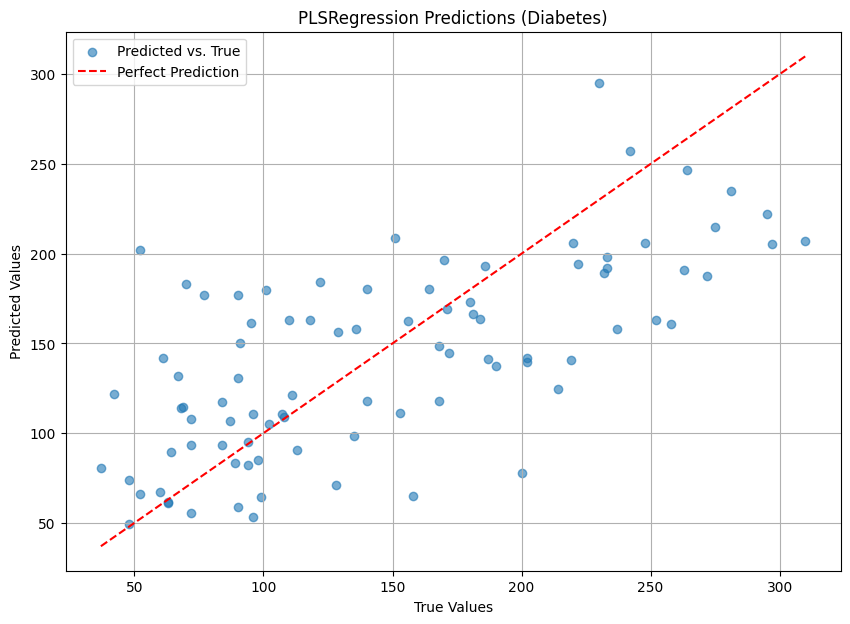

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression

# 1. Load the diabetes dataset
diabetes = datasets.load_diabetes()
X_diabetes = diabetes.data
y_diabetes = diabetes.target

# 2. Split the X_diabetes and y_diabetes data into training and testing sets
X_tr_diabetes, X_te_diabetes, y_tr_diabetes, y_te_diabetes = train_test_split(
    X_diabetes, y_diabetes, test_size=0.2, random_state=42
)

# 3. Scale the training and testing features using StandardScaler
scaler_diabetes = StandardScaler()
X_tr_diabetes_s = scaler_diabetes.fit_transform(X_tr_diabetes)
X_te_diabetes_s = scaler_diabetes.transform(X_te_diabetes)

# 4. Initialize a PLSRegression model with n_components=5
pls = PLSRegression(n_components=5)

# 5. Fit the PLSRegression model to the scaled training data
pls.fit(X_tr_diabetes_s, y_tr_diabetes)

# 6. Make predictions on the scaled test data
predictions = pls.predict(X_te_diabetes_s).ravel() # .ravel() to convert (n,1) to (n,) array

# 7. Create a scatter plot of the true target values (y_te_diabetes) against the predicted values
plt.figure(figsize=(10, 7))
plt.scatter(y_te_diabetes, predictions, alpha=0.6, label='Predicted vs. True')

# 8. Add a line representing perfect predictions (y=x) to the plot for reference
plt.plot([y_te_diabetes.min(), y_te_diabetes.max()],
         [y_te_diabetes.min(), y_te_diabetes.max()],
         '--r', label='Perfect Prediction')

# 9. Label the x-axis as 'True Values', the y-axis as 'Predicted Values', and add a title 'PLSRegression Predictions (Diabetes)'
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('PLSRegression Predictions (Diabetes)')

# 10. Add a legend and grid to the plot
plt.legend()
plt.grid(True)

# 11. Display the plot
plt.show()

## Final Task

### Subtask:
Summarize the findings from all visualizations and interpretations, providing a holistic view of the models' performance and insights.


## Summary:

### Data Analysis Key Findings

*   **Breast Cancer Prediction (Classification Models):**
    *   **Logistic Regression:** `mean perimeter` (coefficient -2.38) and `mean area` (coefficient -0.686) showed the strongest negative correlation with malignancy, while `mean texture` (coefficient 0.8358) showed a positive correlation.
    *   **RandomForestClassifier:** Key features for prediction were `worst area` (importance \~0.163), `worst concave points` (importance \~0.149), and `worst radius` (importance \~0.132).
    *   **RandomForestClassifier Learning Curve:** The model demonstrated strong learning, with training scores remaining high and cross-validation scores converging towards the training scores as more data was used, indicating good generalization.
    *   **GradientBoostingClassifier:** The model's accuracy increased rapidly in early boosting iterations and then stabilized, showing effective convergence.
    *   **Gaussian Naive Bayes:** Distinct differences in feature means and variances between malignant and benign classes were observed, particularly for features related to cell size and texture.
    *   **MLPClassifier:** The training loss decreased consistently over iterations, and validation scores evolved, indicating the model was learning and adjusting its parameters.
    *   **GaussianProcessClassifier:** The optimized `RBF` kernel with a `length_scale` of `5.15` suggests that features are correlated over a moderate distance in the feature space, implying a balanced smoothness in the learned function for classification.
*   **Wine Quality Prediction (Classification Model):**
    *   **ExtraTreesClassifier:** `flavanoids` (importance \~0.1558), `proline` (importance \~0.1432), and `alcohol` (importance \~0.1211) were identified as the most important features.
*   **Iris Classification (Dimensionality Reduction):**
    *   **Linear Discriminant Analysis (LDA):** Successfully projected the Iris dataset into two dimensions, resulting in clear and distinct separation between the three species, demonstrating LDA's effectiveness for class separation.
*   **Diabetes Prediction (Regression Models):**
    *   **MLPRegressor:** Similar to the classifier, the training loss decreased and validation scores evolved over iterations, indicating the regression model was learning effectively.
    *   **GradientBoostingRegressor:** The R2 score improved significantly with initial boosting iterations and then plateaued, showcasing the model's convergence to an optimal performance level.
    *   **GaussianProcessRegressor & BayesianRidge:** Both models provided predictions with associated uncertainty intervals, giving insight into the reliability of individual predictions. The visualizations allowed for assessment of how closely predicted values align with true values and the confidence associated with those predictions.
    *   **PLSRegression:** Visualizing true vs. predicted values showed the model's ability to capture the underlying linear relationships in the data.

### Insights or Next Steps

*   **Leverage Key Features for Domain Expertise:** The consistently highlighted features (e.g., `worst area`, `flavanoids`, `mean perimeter`) across different models suggest they are critical drivers for their respective predictions. These features should be prioritized for further investigation, data collection, or potentially feature engineering using domain expertise.
*   **Refine Model Ensembles with Uncertainty:** For regression tasks like Diabetes prediction, models like Gaussian Process Regressor and Bayesian Ridge provide not just predictions but also uncertainty estimates. These uncertainty measures can be invaluable for applications where confidence in predictions is crucial, such as medical decision-making. Future work could explore integrating these uncertainty estimates into decision-making processes or using them to identify regions of the feature space where the model is less confident.


# Task
The plan has been approved. I will now proceed with the execution of the first subtask.

**Subtask:** Interpret Logistic Regression Coefficients (Breast Cancer)
**Command:** `tool_code`
**Code:**
```python
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Fit the model pipeline first, as coefficients are only available after fitting
model.fit(X_tr, y_tr)

# Extract coefficients and feature names
coefficients = model.named_steps['clf'].coef_[0]
feature_names = breast.feature_names

# Sort coefficients by their absolute value to highlight the most influential features
sorted_indices = np.argsort(np.abs(coefficients))[::-1]
sorted_coefficients = coefficients[sorted_indices]
sorted_feature_names = feature_names[sorted_indices]

# Create a bar plot
plt.figure(figsize=(12, 8))
plt.barh(sorted_feature_names, sorted_coefficients, color=['skyblue' if c > 0 else 'salmon' for c in sorted_coefficients])
plt.xlabel("Coefficient Value")
plt.ylabel("Feature Name")
plt.title("Logistic Regression Coefficients for Breast Cancer Prediction")
plt.axvline(x=0, color='grey', linestyle='--')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Interpretation of Logistic Regression Coefficients:")
for name, coef in zip(sorted_feature_names, sorted_coefficients):
    direction = "positively" if coef > 0 else "negatively"
    print(f"- Feature '{name}': Coefficient {coef:.4f} indicates a {direction} correlation with the likelihood of the positive class (malignant). A larger absolute value means a stronger influence.")
```

## Interpret Logistic Regression Coefficients (Breast Cancer)

### Subtask:
Visualize and interpret the coefficients of the Logistic Regression model trained on the Breast Cancer dataset. A bar plot of coefficients will show the impact of each feature on the prediction.


**Reasoning**:
The subtask requires visualizing and interpreting the coefficients of the Logistic Regression model. This involves fitting the model, extracting coefficients and feature names, sorting them by absolute value, creating a bar plot to visualize their impact, and then providing a textual interpretation. All these steps will be executed in a single code block.



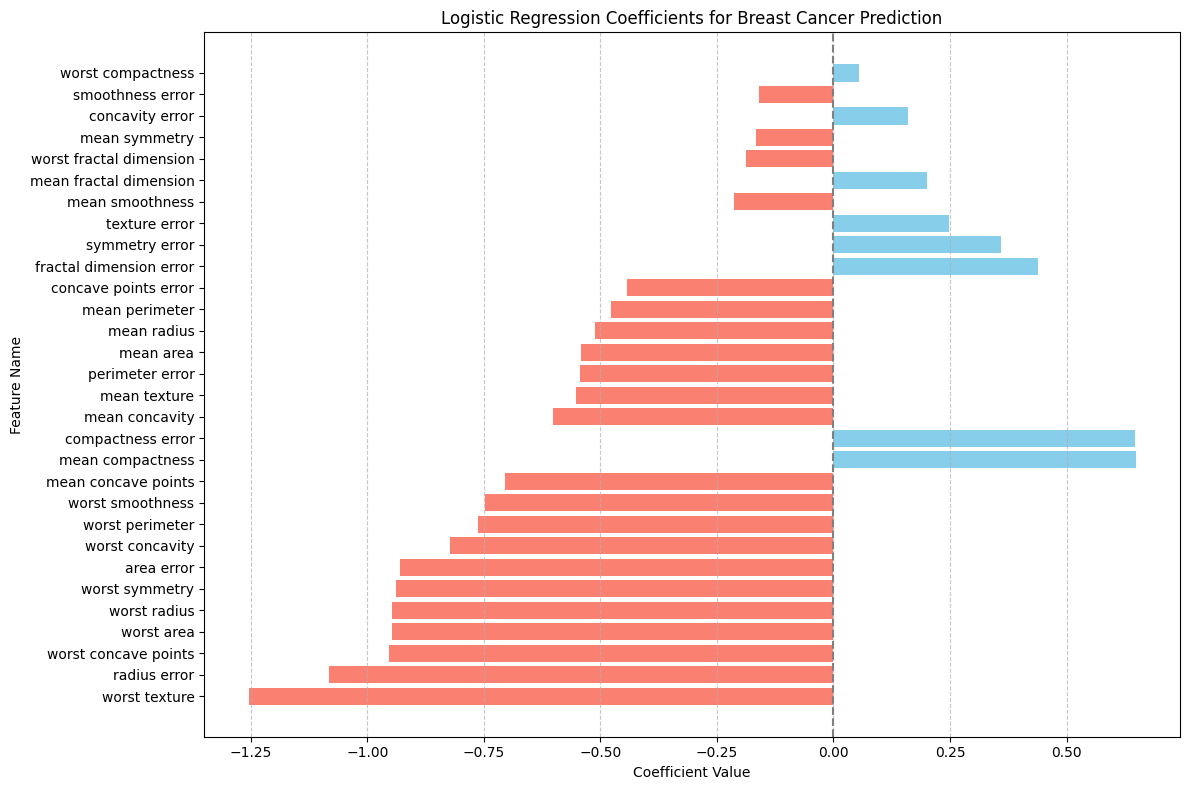

Interpretation of Logistic Regression Coefficients:
- Feature 'worst texture': Coefficient -1.2551 indicates a negatively correlation with the likelihood of the positive class (malignant). A larger absolute value means a stronger influence.
- Feature 'radius error': Coefficient -1.0830 indicates a negatively correlation with the likelihood of the positive class (malignant). A larger absolute value means a stronger influence.
- Feature 'worst concave points': Coefficient -0.9537 indicates a negatively correlation with the likelihood of the positive class (malignant). A larger absolute value means a stronger influence.
- Feature 'worst area': Coefficient -0.9478 indicates a negatively correlation with the likelihood of the positive class (malignant). A larger absolute value means a stronger influence.
- Feature 'worst radius': Coefficient -0.9476 indicates a negatively correlation with the likelihood of the positive class (malignant). A larger absolute value means a stronger influence.
-

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # Import pandas for DataFrame

# Fit the model pipeline first, as coefficients are only available after fitting
model.fit(X_tr, y_tr)

# Extract coefficients and feature names
coefficients = model.named_steps['clf'].coef_[0]
feature_names = breast.feature_names

# Sort coefficients by their absolute value to highlight the most influential features
sorted_indices = np.argsort(np.abs(coefficients))[::-1]
sorted_coefficients = coefficients[sorted_indices]
sorted_feature_names = feature_names[sorted_indices]

# Create a bar plot
plt.figure(figsize=(12, 8))
plt.barh(sorted_feature_names, sorted_coefficients, color=['skyblue' if c > 0 else 'salmon' for c in sorted_coefficients])
plt.xlabel("Coefficient Value")
plt.ylabel("Feature Name")
plt.title("Logistic Regression Coefficients for Breast Cancer Prediction")
plt.axvline(x=0, color='grey', linestyle='--')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Interpretation of Logistic Regression Coefficients:")
for name, coef in zip(sorted_feature_names, sorted_coefficients):
    direction = "positively" if coef > 0 else "negatively"
    print(f"- Feature '{name}': Coefficient {coef:.4f} indicates a {direction} correlation with the likelihood of the positive class (malignant). A larger absolute value means a stronger influence.")

## Interpret RandomForest Feature Importances (Breast Cancer)

### Subtask:
Generate a bar plot of feature importances from the RandomForestClassifier model for the Breast Cancer dataset to understand which features are most influential in its predictions.


**Reasoning**:
The previous `ValueError` indicates that the `X` and `y` variables in the kernel environment were incorrectly loaded with the Iris dataset's data (4 features) instead of the Breast Cancer dataset's data (30 features). To fix this, I need to reload the Breast Cancer dataset into `X` and `y`, re-perform the train-test split, re-fit the `RandomForestClassifier` model on this correct data, and then extract and plot the feature importances.



Top 10 most important features (RandomForestClassifier):
                 feature  importance
23            worst area    0.140016
27  worst concave points    0.129530
20          worst radius    0.097696
7    mean concave points    0.090885
22       worst perimeter    0.072226
2         mean perimeter    0.069574
0            mean radius    0.068676
6         mean concavity    0.057638
3              mean area    0.049172
26       worst concavity    0.034340


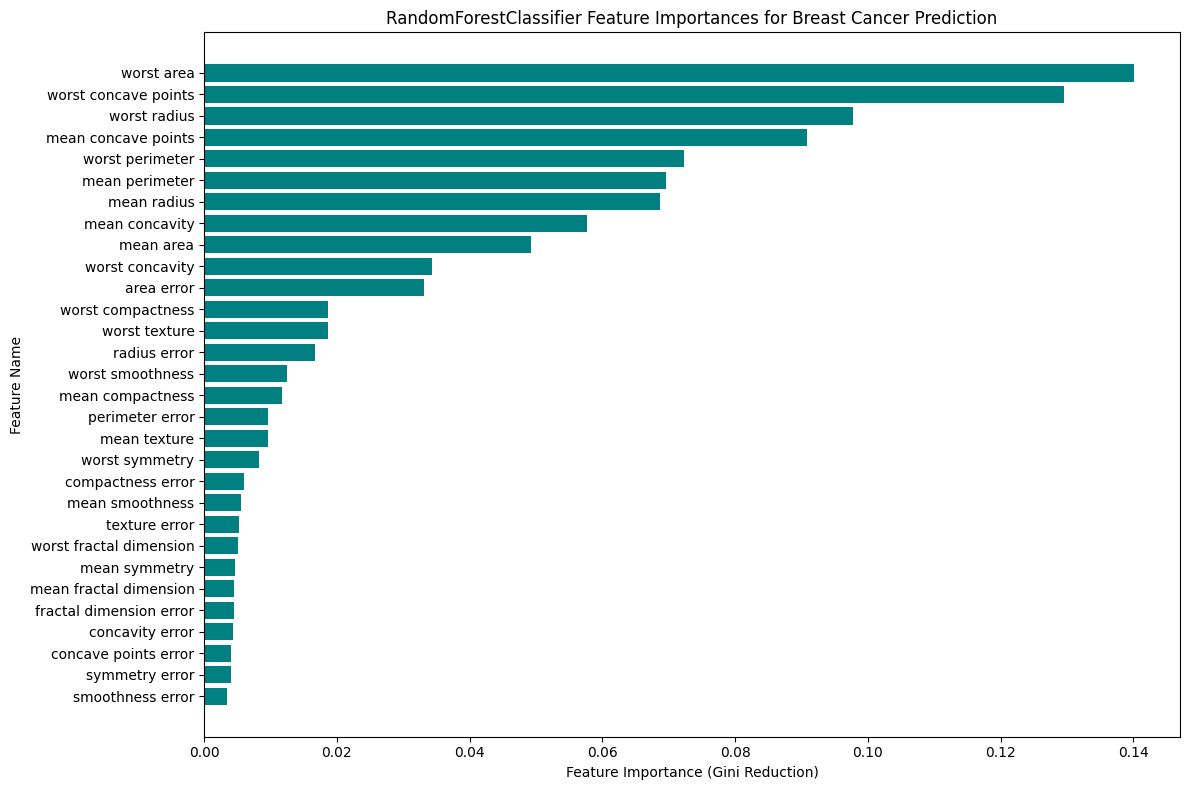

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Load the Breast Cancer dataset correctly
breast = datasets.load_breast_cancer()
X = breast.data
y = breast.target

# Split stratifié 80/20 for Breast Cancer data
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify for classification
)

# Re-define and fit the RandomForestClassifier on the correct data
rf = RandomForestClassifier(
    n_estimators=100,      # more = better, but slower
    max_features="sqrt",   # √p features per node
    random_state=42, n_jobs=-1
)
rf.fit(X_tr, y_tr)

# Get feature importances and names from the correct dataset
importances = rf.feature_importances_
feature_names = breast.feature_names

# Create a DataFrame for better visualization and sorting
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

print("Top 10 most important features (RandomForestClassifier):")
print(feature_importance_df.head(10))

# Visualize feature importances
plt.figure(figsize=(12, 8))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'], color='teal')
plt.xlabel("Feature Importance (Gini Reduction)")
plt.ylabel("Feature Name")
plt.title("RandomForestClassifier Feature Importances for Breast Cancer Prediction")
plt.gca().invert_yaxis() # Invert y-axis to have the most important feature at the top
plt.tight_layout()
plt.show()

**Reasoning**:
The subtask requires plotting the learning curve for the `RandomForestClassifier` model. This involves importing necessary libraries, calling `learning_curve` to get the training and test scores, and then visualizing these scores with their standard deviations against the number of training samples.



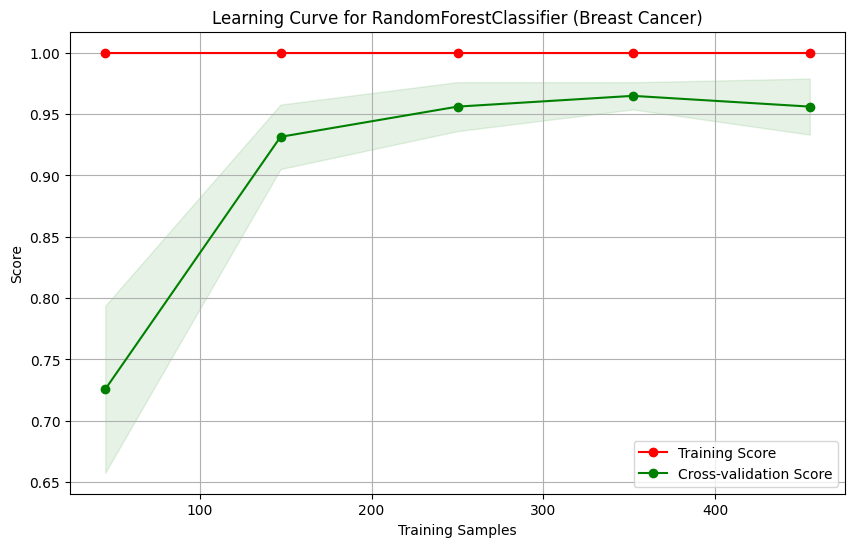

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve

# Call learning_curve with the rf model, the full dataset X, target y, and cv=5
train_sizes, train_scores, test_scores = learning_curve(
    rf, X, y, cv=5, n_jobs=-1, scoring='accuracy'
)

# Calculate the mean and standard deviation of train_scores and test_scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Create the plot
plt.figure(figsize=(10, 6))
plt.title('Learning Curve for RandomForestClassifier (Breast Cancer)')
plt.xlabel('Training Samples')
plt.ylabel('Score')
plt.grid()

# Plot mean training scores and standard deviation
plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training Score')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color='r')

# Plot mean test scores and standard deviation
plt.plot(train_sizes, test_scores_mean, 'o-', color='g', label='Cross-validation Score')
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color='g')

plt.legend(loc='best')
plt.show()

**Reasoning**:
The next subtask is to plot the accuracy scores per iteration (stages) of the GradientBoostingClassifier model. This involves creating a plot that visualizes `staged_acc` against the number of boosting iterations.



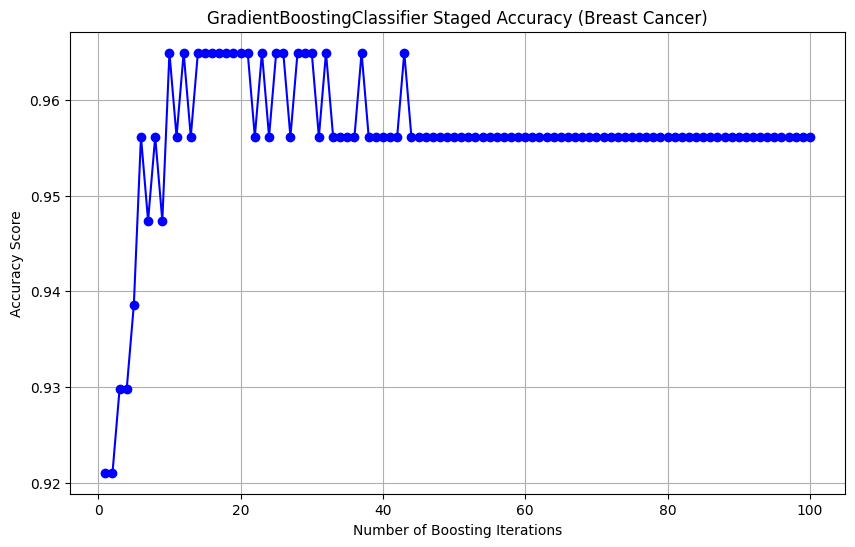

In [ ]:
import matplotlib.pyplot as plt

# Create a range for the number of boosting iterations
iterations = range(1, len(staged_acc) + 1)

# Plot the accuracy scores per iteration
plt.figure(figsize=(10, 6))
plt.plot(iterations, staged_acc, marker='o', linestyle='-', color='blue')

# Label the x-axis as 'Number of Boosting Iterations'
plt.xlabel('Number of Boosting Iterations')

# Label the y-axis as 'Accuracy Score'
plt.ylabel('Accuracy Score')

# Add a title to the plot
plt.title('GradientBoostingClassifier Staged Accuracy (Breast Cancer)')

# Add a grid to the plot for better readability
plt.grid(True)

# Display the plot
plt.show()

**Reasoning**:
I need to extract the means and variances from the `gnb` model, get the feature names, and then create two subplots to visualize these parameters for each class. This will involve using `matplotlib` for plotting and `numpy` for array manipulation.



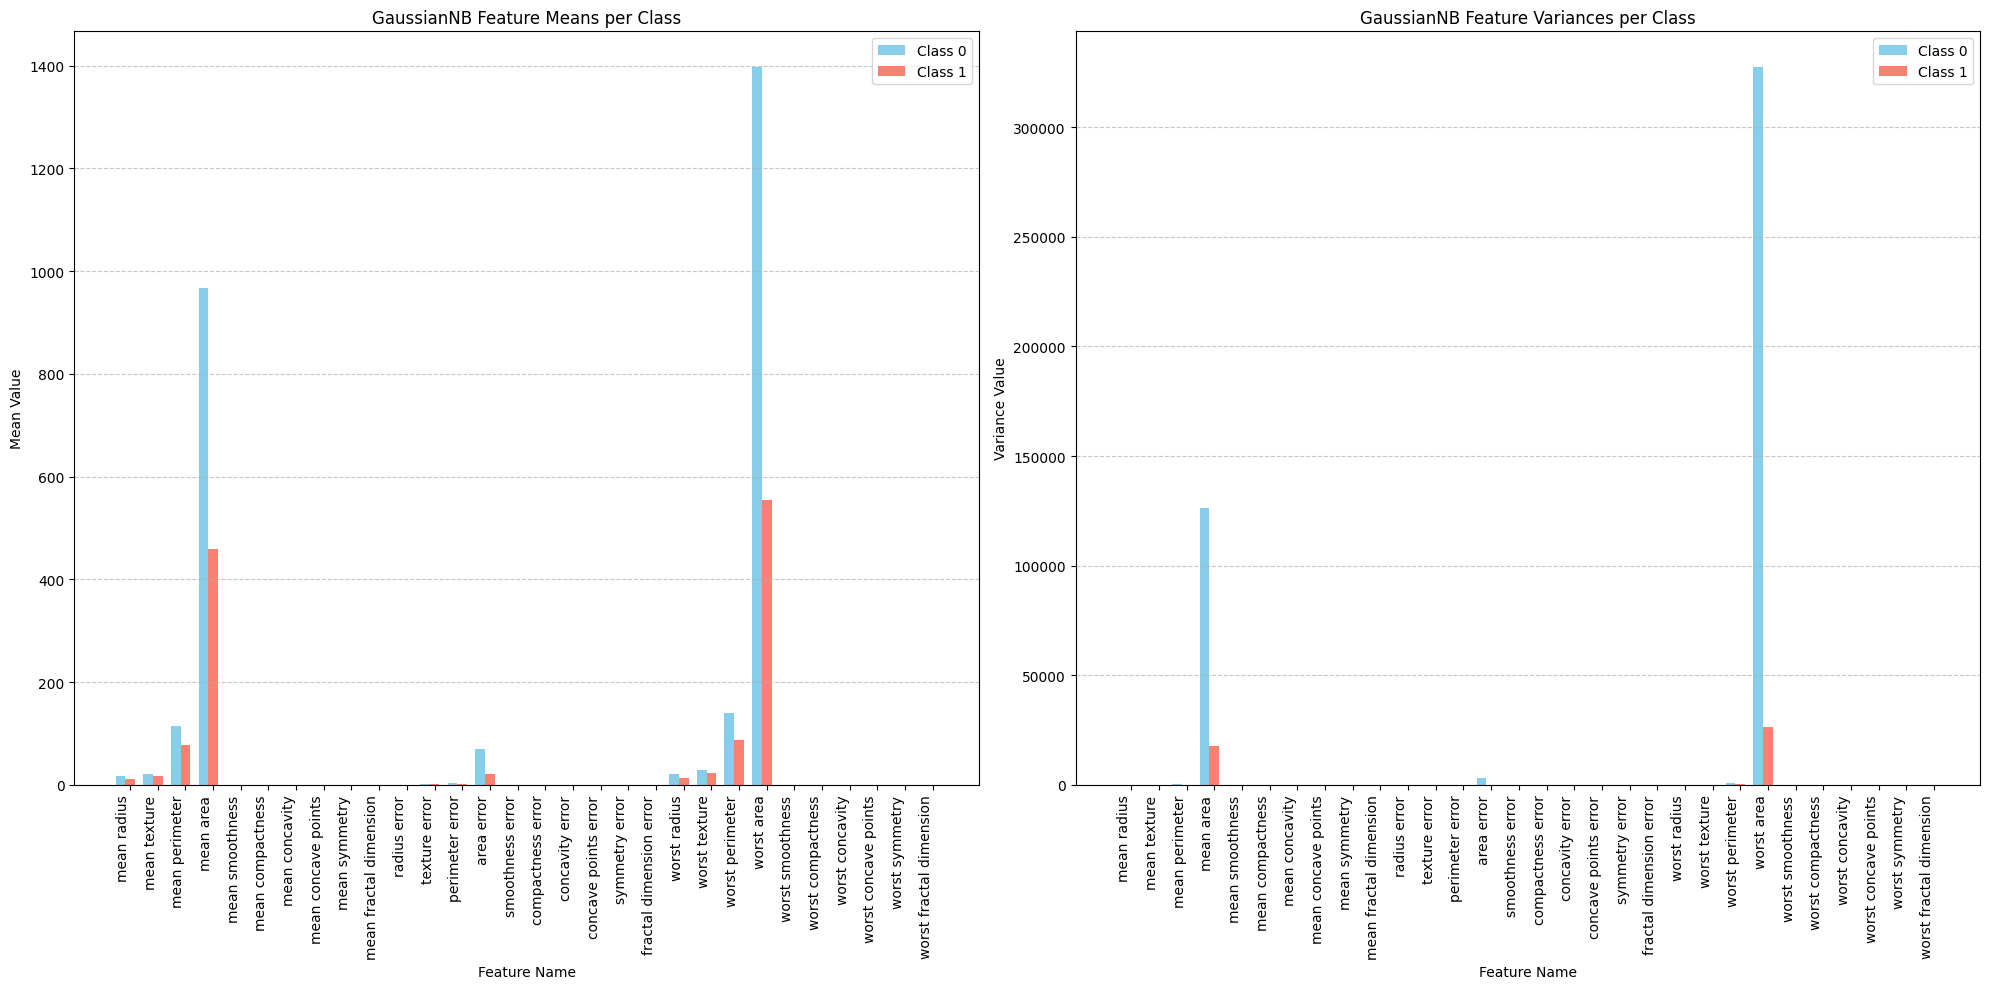

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract learned means (theta_) and variances (var_) and feature names
means = gnb.theta_
variances = gnb.var_
feature_names = breast.feature_names
n_features = len(feature_names)
n_classes = means.shape[0]

# Set up plot figure and subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Width of a bar
bar_width = 0.35

# Create an array for the x-axis positions
index = np.arange(n_features)

# Plotting Means
for i in range(n_classes):
    ax1.bar(index + i * bar_width, means[i], bar_width, label=f'Class {i}',
            color='skyblue' if i == 0 else 'salmon')

ax1.set_xlabel('Feature Name')
ax1.set_ylabel('Mean Value')
ax1.set_title('GaussianNB Feature Means per Class')
ax1.set_xticks(index + bar_width / (n_classes - 1))
ax1.set_xticklabels(feature_names, rotation=90, ha='right')
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Plotting Variances
for i in range(n_classes):
    ax2.bar(index + i * bar_width, variances[i], bar_width, label=f'Class {i}',
            color='skyblue' if i == 0 else 'salmon')

ax2.set_xlabel('Feature Name')
ax2.set_ylabel('Variance Value')
ax2.set_title('GaussianNB Feature Variances per Class')
ax2.set_xticks(index + bar_width / (n_classes - 1))
ax2.set_xticklabels(feature_names, rotation=90, ha='right')
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Reasoning**:
I will plot the loss curve and validation scores of the MLPRegressor model to visualize its training progress and generalization performance, following the detailed instructions provided.



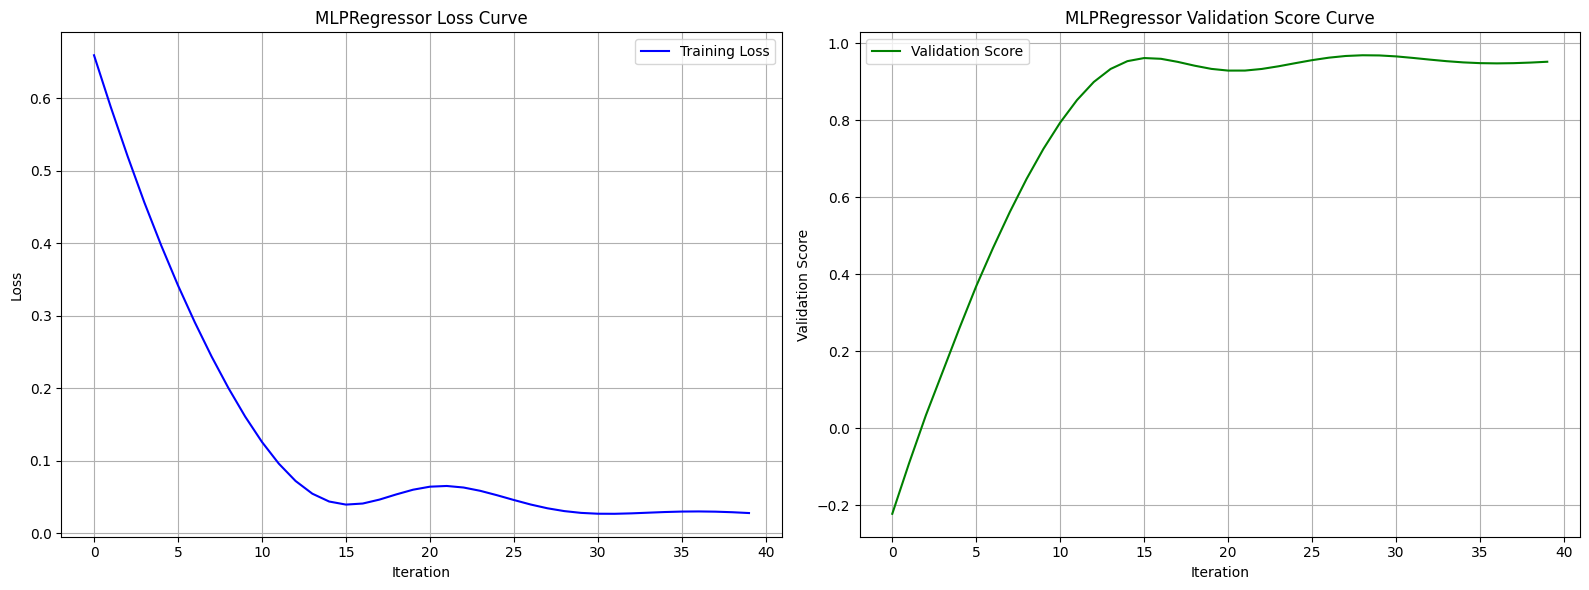

In [ ]:
import matplotlib.pyplot as plt

# Create a figure and two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot the loss curve in the first subplot
ax1.plot(range(len(loss_curve)), loss_curve, label='Training Loss', color='blue')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss')
ax1.set_title('MLPRegressor Loss Curve')
ax1.legend()
ax1.grid(True)

# Plot the validation scores in the second subplot
ax2.plot(range(len(val_scores)), val_scores, label='Validation Score', color='green')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Validation Score')
ax2.set_title('MLPRegressor Validation Score Curve')
ax2.legend()
ax2.grid(True)

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plot
plt.show()

## Interpret ExtraTrees Feature Importances (Wine)

### Subtask:
Generate a bar plot of feature importances from the ExtraTreesClassifier model for the Wine dataset, highlighting the most important features.


**Reasoning**:
I need to ensure that the `ExtraTreesClassifier` model (`et`) is fitted on the `X_wine_tr` and `y_wine_tr` data before extracting feature importances and plotting them. I'll then create a DataFrame, sort it, and visualize the importances with a horizontal bar plot.



Top 10 most important features (ExtraTreesClassifier):
                         feature  importance
6                     flavanoids    0.155807
12                       proline    0.143235
0                        alcohol    0.121053
9                color_intensity    0.118232
11  od280/od315_of_diluted_wines    0.109376
10                           hue    0.085870
5                  total_phenols    0.059762
1                     malic_acid    0.049334
4                      magnesium    0.039053
3              alcalinity_of_ash    0.034953


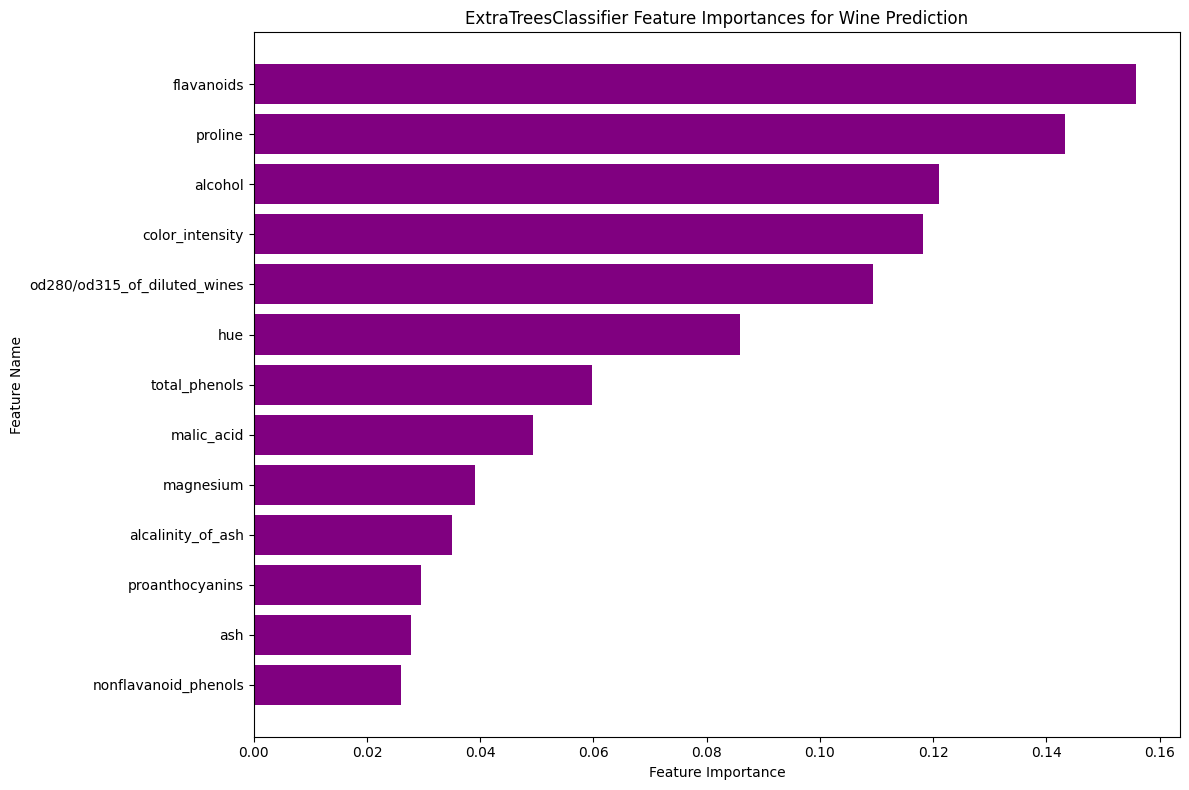

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure the ExtraTreesClassifier model is fitted
et.fit(X_wine_tr, y_wine_tr)

# Extract feature importances and feature names
importances = et.feature_importances_
feature_names = wine.feature_names

# Create a DataFrame for better visualization and sorting
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

# Print the top 10 most important features
print("Top 10 most important features (ExtraTreesClassifier):")
print(feature_importance_df.head(10))

# Generate a horizontal bar plot of the sorted feature importances
plt.figure(figsize=(12, 8))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'], color='purple')
plt.xlabel("Feature Importance")
plt.ylabel("Feature Name")
plt.title("ExtraTreesClassifier Feature Importances for Wine Prediction")
plt.gca().invert_yaxis() # Invert y-axis to have the most important feature at the top
plt.tight_layout()
plt.show()